# Summaries Analysis

This notebook performs both **quantitative** and **qualitative** analyses of the summaries generated by the API, to build a complete picture of model summary performance.





**1. Quantitative Analysis**
- Conduct a **statistical and exploratory data analysis** of the API results using Pandas and descriptive statistics.  
- Explore and refine the **visualizations** to better highlight differences and distributions.  
- Compare **model runtimes** (CPU vs GPU) for the same document to assess performance efficiency.  



**1. Qualitative Analysis**
- **Garbage Detection:** Identify low-quality or nonsensical summaries (e.g., hallucinations or “garbage” outputs).  
  These can often be detected as **outliers** in the quantitative performance metrics.  
  DeepSeek has shown clear examples of this behavior.  
- **Summary Comparison:** Evaluate the **relative quality and performance** of summaries across different models, linking the findings with the quantitative metrics.


## Quantitative Analysis

#### Load data and function definitions

In [142]:
# Libraries imports

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Function definitions

In [143]:
# Attempt to identify parameter scale (in billions) from model names
def get_model_parameter_scale(model_name):

    import re
    if not model_name:
        return None

    known_params = {
        "gemma3:12b": 12,
        "gemma3:40b": 40,
        "gemma3:20b": 20,
        "gemma3:22b": 22,
        "gemma3:38b": 38,
        "llama3.1:8b": 8,
        "llama3.2:3b": 3,
        "llama3.2:11b": 11,
        "deepseek-r1:1.1b": 1.1,
        "deepseek-r1:1b": 1,
        "phi-3:3.8b": 3.8,
        "phi-4:14b": 14,
        "qwen3:3.8b": 3.8,
        "qwen3:14b": 14,
        "qwen3:72b": 72,
    }

    model_name_lower = model_name.lower()
    if model_name_lower in known_params:
        return known_params[model_name_lower]

    match = re.search(r"(\d+(?:\.\d+)?)\s*b", model_name_lower)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            return None
    return None

def unique_vals(df, col):
    print(col)
    return print(f"Total {col}: {(df[col].nunique())} \n {(df[col].unique())} \n")


In [144]:
DATA_PATH = '/Users/sofi/Desktop/collectiveAI/'
cuda_summaries_file = os.path.join(DATA_PATH, 'summarization-benchmark-results-cuda.json')
cpu_summaries_file = os.path.join(DATA_PATH, 'summarization-benchmark-results-cpu.json')

with open(cuda_summaries_file, 'r') as f:
    cuda_summaries = json.load(f)
with open(cpu_summaries_file, 'r') as f:
    cpu_summaries = json.load(f)

summaries = cuda_summaries + cpu_summaries
df = pd.DataFrame(summaries)

In [145]:
df.doc_path.nunique()

18

In [146]:
df.doc_path = df.doc_path.apply(lambda x: os.path.basename(x))
df.doc_path.nunique()

9

### Descriptive analysis

In [147]:
df.head(4)

,model,options,system_prompt,user_prompt,chat_response,input_tokens,input_duration_ms,output_tokens,output_duration_ms,total_tokens,model_duration_ms,measured_duration_ms,tokens_per_second,raw_response,doc_path,device,system_prompt_type
0,llama3.1:8b,{'num_ctx': 16384},Eres un asistente especializado en resumir doc...,CUIJ J-01-00369422-0/2022-1 EXP. MPT 13904/202...,El dictamen del Asesor de Cámara Ernesto Blanc...,7405,9855.794521,593,44551.506973,7998,58063.681855,58066.752911,13.310436,"{'model': 'llama3.1:8b', 'created_at': '2025-1...","1- FLORES ABARCA, Francisco Alexander s 149 bi...",cuda,baseline
1,llama3.1:8b,{'num_ctx': 16384},Eres un analista legal especializado en elabor...,CUIJ J-01-00369422-0/2022-1 EXP. MPT 13904/202...,**Resumen del documento**\n\nEl presente docum...,7438,9910.695895,411,30714.751956,7849,40775.564339,40777.994633,13.381192,"{'model': 'llama3.1:8b', 'created_at': '2025-1...","1- FLORES ABARCA, Francisco Alexander s 149 bi...",cuda,task-specific
2,llama3.1:8b,{'num_ctx': 16384},Eres un asistente especializado en el análisis...,CUIJ J-01-00369422-0/2022-1 EXP. MPT 13904/202...,**Resumen del documento**\n\nEl documento es u...,8173,10951.313583,782,59626.991721,8955,70755.397316,70757.712364,13.114866,"{'model': 'llama3.1:8b', 'created_at': '2025-1...","1- FLORES ABARCA, Francisco Alexander s 149 bi...",cuda,template
3,llama3.2:3b,{'num_ctx': 16384},Eres un asistente especializado en resumir doc...,CUIJ J-01-00369422-0/2022-1 EXP. MPT 13904/202...,Resumen del Dictamen:\n\nEl dictamen se refier...,7415,4215.624386,402,6071.661954,7817,13892.841249,13895.484686,66.209220,"{'model': 'llama3.2:3b', 'created_at': '2025-1...","1- FLORES ABARCA, Francisco Alexander s 149 bi...",cuda,baseline


#### Prompts visualization/print

In [148]:
import pprint
unique = df[['system_prompt','system_prompt_type']].drop_duplicates().reset_index(drop=True)

for _, row in unique.iterrows():
    print("Type:", row['system_prompt_type'])
    print("Prompt:")
    pprint.pprint(row['system_prompt'])
    print("---\n")

Type: baseline
Prompt:
('Eres un asistente especializado en resumir documentos.\n'
 'Tu único objetivo es producir un resumen fiel, claro y conciso del texto que '
 'recibirás.\n'
 'No añadas interpretaciones ni conclusiones no presentes en el documento.\n')
---

Type: task-specific
Prompt:
('Eres un analista legal especializado en elaborar resúmenes de resoluciones y '
 'documentos jurídicos.\n'
 'Tu tarea es condensar la información esencial: hechos, cuestiones jurídicas, '
 'fundamentos y decisión.\n'
 'Mantén precisión terminológica y evita inferencias no textuales. Si algún '
 'elemento no aparece en el texto, no lo inventes.\n')
---

Type: template
Prompt:
('Eres un asistente especializado en el análisis de documentos judiciales.\n'
 'Debes elaborar un resumen conciso del texto recibido, priorizando la '
 'información más relevante e identificando:\n'
 '\n'
 '\n'
 '    - Hechos relevantes (qué ocurrió).\n'
 '    - Actores clave (quiénes están involucrados).\n'
 '        * Denunci

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   model                 648 non-null    object 
 1   options               648 non-null    object 
 2   system_prompt         648 non-null    object 
 3   user_prompt           648 non-null    object 
 4   chat_response         648 non-null    object 
 5   input_tokens          648 non-null    int64  
 6   input_duration_ms     648 non-null    float64
 7   output_tokens         648 non-null    int64  
 8   output_duration_ms    648 non-null    float64
 9   total_tokens          648 non-null    int64  
 10  model_duration_ms     648 non-null    float64
 11  measured_duration_ms  648 non-null    float64
 12  tokens_per_second     648 non-null    float64
 13  raw_response          648 non-null    object 
 14  doc_path              648 non-null    object 
 15  device                6

#### Data engineer (ms -> mins)

Create new columns to mins unit

In [150]:
ms_cols = [c for c in df.columns if c.endswith('ms')]
ms_min_cols = [[c.replace('ms', 'min'), c] for c in ms_cols]
time_cols = [c[0] for c in ms_min_cols]

for cols in ms_min_cols:
    c, ms_col = cols
    df[c] = df[ms_col] / 1000 / 60

df.head(2)

time_cols

['input_duration_min',
 'output_duration_min',
 'model_duration_min',
 'measured_duration_min']

#### Describe columns

We describe the float type columns:

In [151]:
desc = df[['input_tokens', 'output_tokens', 'total_tokens', 
           'input_duration_min', 'output_duration_min', 
           'model_duration_min', 'tokens_per_second']].describe().T
print(desc)

                     count          mean           std         min  \
input_tokens         648.0   7083.725309   5220.735846  657.000000   
output_tokens        648.0   3483.907407  20175.381094   41.000000   
total_tokens         648.0  10567.632716  21111.693751  772.000000   
input_duration_min   648.0      2.798999      4.288023    0.003143   
output_duration_min  648.0      7.900752     45.131076    0.030909   
model_duration_min   648.0     10.840433     45.317622    0.075952   
tokens_per_second    648.0     14.255853     19.054841    1.798987   

                             25%          50%           75%            max  
input_tokens         1482.000000  7276.500000  10350.500000   16384.000000  
output_tokens         470.500000   734.000000   1123.000000  163840.000000  
total_tokens         2502.750000  7967.000000  11870.250000  180002.000000  
input_duration_min      0.194695     0.839950      3.928114      28.762716  
output_duration_min     0.701544     1.935107      4.0

In [152]:
840 / 60

14.0

We observed that the 75% of the results have model_duration_min <= 7.7 minutes, and the is at list one outlier with model_duration_min = 840 minutes (14 hours)

In [153]:
df[df['model_duration_min']>840]

,model,options,system_prompt,user_prompt,chat_response,input_tokens,input_duration_ms,output_tokens,output_duration_ms,total_tokens,...,measured_duration_ms,tokens_per_second,raw_response,doc_path,device,system_prompt_type,input_duration_min,output_duration_min,model_duration_min,measured_duration_min
460,deepseek-r1:8b,{'num_ctx': 16384},Eres un asistente especializado en el análisis...,JUZGADO DE FAMILIA N.o 2 DE LA CIUDAD DE PUERT...,<think>\n</think>\n```markdown\n\n**Resumen de...,1963,49363.797064,163840,5.035604e+07,165803,...,5.040555e+07,3.253632,"{'model': 'deepseek-r1:8b', 'created_at': '202...",aymurai - ejemplo 03.docx,cpu,template,0.82273,839.267302,840.092394,840.092553


This is an outlier due the garbage of its output:

In [154]:
import pprint
df[df['model_duration_min']>840].chat_response.iloc[0][-200:]

'  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:  \n:'

Visualization of unique values per main columns:

In [155]:
for col in ['model','system_prompt','device','system_prompt_type','user_prompt','doc_path']:
    unique_vals(df,col)

model
Total model: 12 
 ['llama3.1:8b' 'llama3.2:3b' 'gemma3:4b' 'gemma3n:e4b' 'gemma3:12b'
 'qwen3:8b' 'qwen3:14b' 'phi3:3.8b' 'phi4:14b' 'deepseek-r1:8b'
 'deepseek-r1:14b' 'gpt-oss:20b'] 

system_prompt
Total system_prompt: 3 
 ['Eres un asistente especializado en resumir documentos.\nTu único objetivo es producir un resumen fiel, claro y conciso del texto que recibirás.\nNo añadas interpretaciones ni conclusiones no presentes en el documento.\n'
 'Eres un analista legal especializado en elaborar resúmenes de resoluciones y documentos jurídicos.\nTu tarea es condensar la información esencial: hechos, cuestiones jurídicas, fundamentos y decisión.\nMantén precisión terminológica y evita inferencias no textuales. Si algún elemento no aparece en el texto, no lo inventes.\n'
 'Eres un asistente especializado en el análisis de documentos judiciales.\nDebes elaborar un resumen conciso del texto recibido, priorizando la información más relevante e identificando:\n\n\n    - Hechos relevantes

### Model comparison

In [156]:
df.groupby('model')[['tokens_per_second', 'model_duration_min', 'total_tokens']].mean().sort_values('tokens_per_second', ascending=False)
df.groupby(['model', 'device'])[['model_duration_min', 'tokens_per_second']].mean()

model_duration_min  tokens_per_second
model           device                                       
deepseek-r1:14b cpu              13.814217           2.505725
                cuda              3.898669           4.599383
deepseek-r1:8b  cpu              42.352947           4.150759
                cuda             91.485099          20.251961
gemma3:12b      cpu               7.309431           3.343964
                cuda              2.323687           9.329835
gemma3:4b       cpu               2.626062           9.405372
                cuda              0.280615          64.403980
gemma3n:e4b     cpu               4.010992           8.177186
                cuda              0.799720          25.401282
gpt-oss:20b     cpu              10.282862           5.440994
                cuda              5.419878           8.456999
llama3.1:8b     cpu               6.382437           4.556869
                cuda              0.852579          24.461310
llama3.2:3b     cpu               3.285957           8.779649
                cuda              0.298174          66.192878
phi3:3.8b       cpu               6.795000           5.463181
                cuda              2.980261          26.340620
phi4:14b        cpu              12.086207           2.571019
                cuda              3.306276           4.596641
qwen3:14b       cpu              17.552210           2.536454
                cuda              9.281708           5.101298
qwen3:8b        cpu              10.149288           4.185300
                cuda              2.596128          21.887802

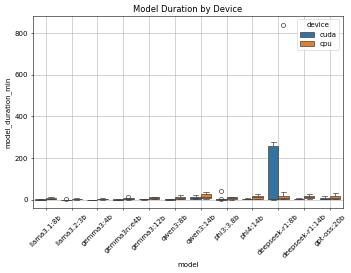

In [157]:
# Runtime distribution
plt.figure(figsize=(8,5),dpi = 50)
sns.boxplot(data=df, x='model', y='model_duration_min', hue='device')
plt.xticks(rotation=45)
plt.title("Model Duration by Device")
plt.grid(True) 
plt.show()

Since deepseek-r1:8b has a duration one or two orders of magnitude longer compared to other models, we removed it from the visualization to avoid scaling issues:

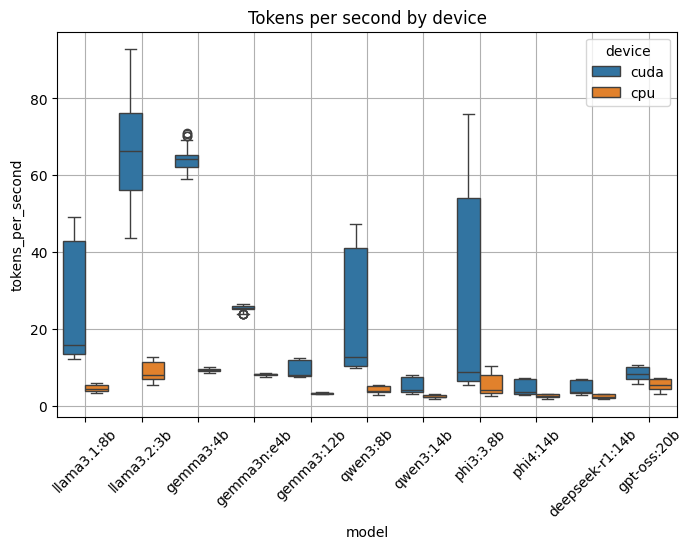

In [158]:
df_to_plot = df[df['model'] != 'deepseek-r1:8b']
# Runtime distribution
plt.figure(figsize=(8,5),dpi = 100)
sns.boxplot(data=df_to_plot, x='model', y='tokens_per_second', hue='device')
plt.xticks(rotation=45)
plt.title("Tokens per second by device")
plt.grid(True) 
plt.show()

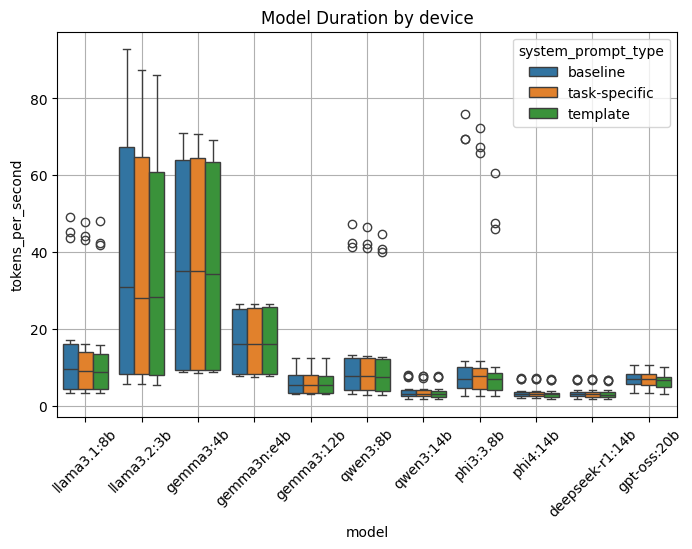

In [159]:
df_to_plot = df[df['model'] != 'deepseek-r1:8b']
# Runtime distribution
plt.figure(figsize=(8,5),dpi = 100)
sns.boxplot(data=df_to_plot, x='model', y='tokens_per_second', hue='system_prompt_type')
plt.xticks(rotation=45)
plt.title("Model Duration by device")
plt.grid(True) 
plt.show()

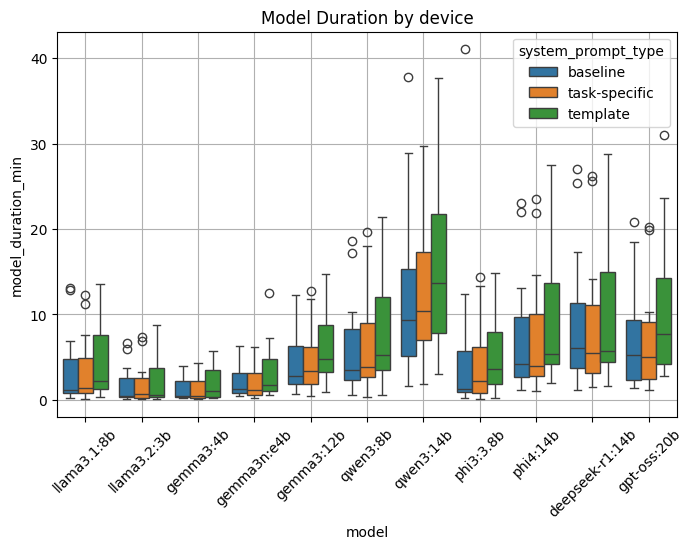

In [160]:
df_to_plot = df[df['model'] != 'deepseek-r1:8b']
# Runtime distribution
plt.figure(figsize=(8,5),dpi = 100)
sns.boxplot(data=df_to_plot, x='model', y='model_duration_min', hue='system_prompt_type')
plt.xticks(rotation=45)
plt.title("Model Duration by device")
plt.grid(True) 
plt.show()

It can be seen how much better cuda performs over cpu

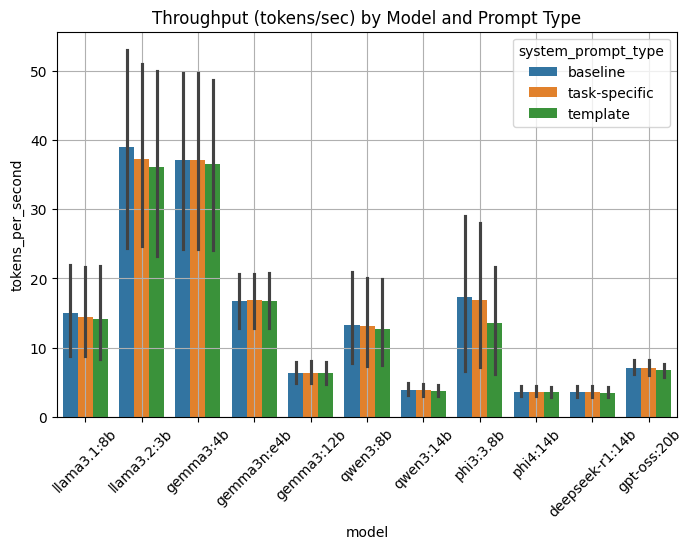

In [161]:
# Throughput
plt.figure(figsize=(8,5),dpi = 100)
sns.barplot(data=df_to_plot, x='model', y='tokens_per_second', hue='system_prompt_type')
plt.xticks(rotation=45)
plt.grid(True) 
plt.title("Throughput (tokens/sec) by Model and Prompt Type")
plt.show()

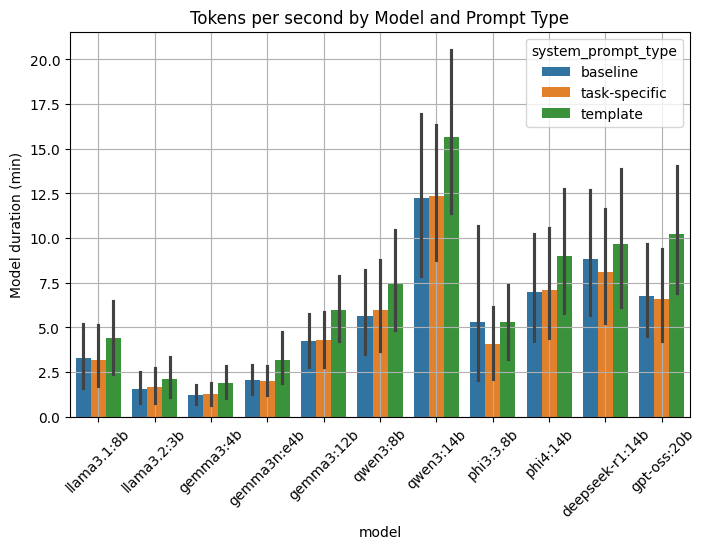

In [162]:
# Throughput
plt.figure(figsize=(8,5),dpi = 100)
sns.barplot(data=df_to_plot, x='model', y='model_duration_min', hue='system_prompt_type')
plt.xticks(rotation=45)
plt.grid(True) 
plt.ylabel('Model duration (min)')
plt.title("Tokens per second by Model and Prompt Type")
plt.show()

/var/folders/yf/2cttyjmx5j35yhq4st33mdmm0000gn/T/ipykernel_20340/2481501827.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot['compression_ratio'] = df_to_plot['output_tokens'] / df['input_tokens']


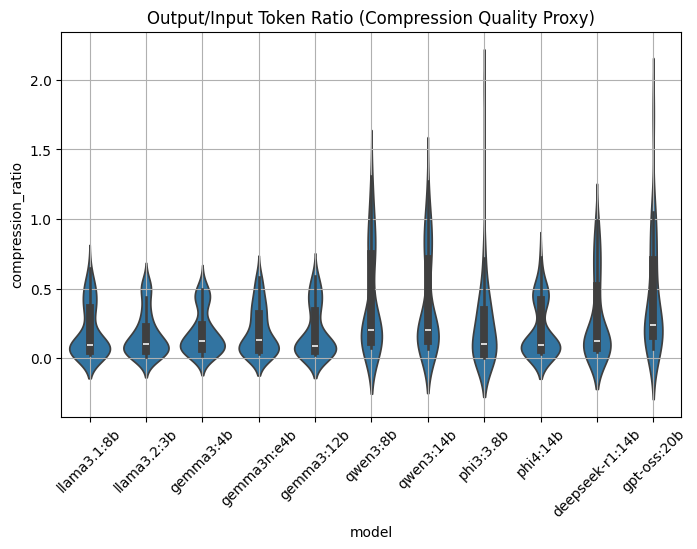

In [163]:
# Token ratios
plt.figure(figsize=(8,5),dpi = 100)
df_to_plot['compression_ratio'] = df_to_plot['output_tokens'] / df['input_tokens']
sns.violinplot(data=df_to_plot, x='model', y='compression_ratio')
plt.xticks(rotation=45)
plt.grid(True) 
plt.title("Output/Input Token Ratio (Compression Quality Proxy)")
plt.show()


A nivel 

The mean imput tokens by model are:

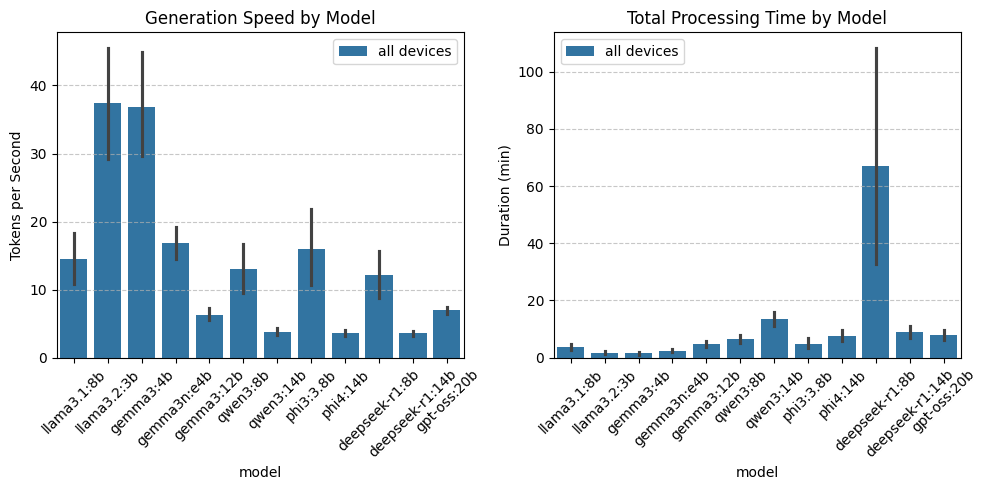

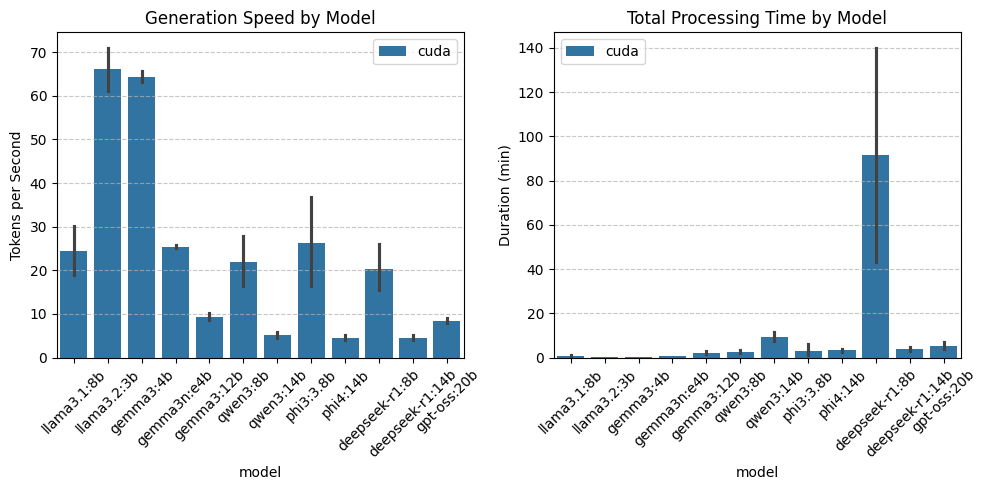

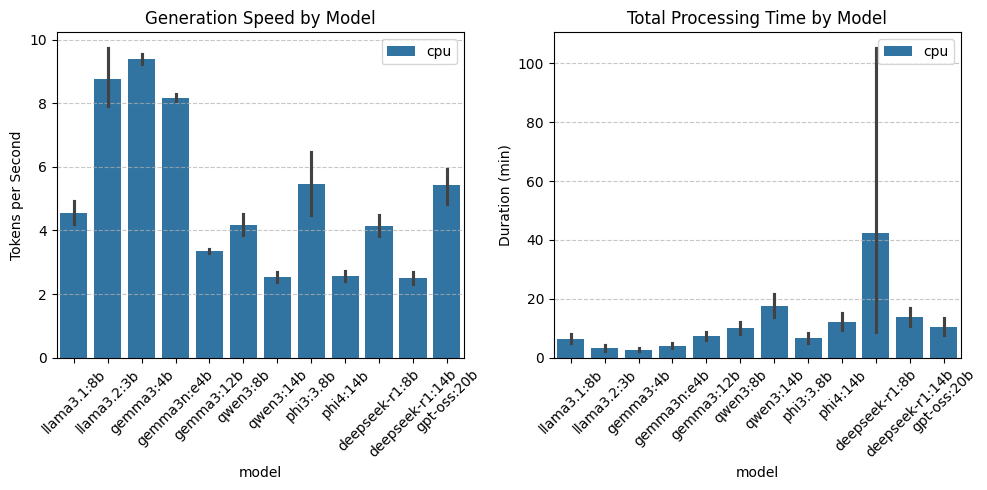

In [164]:
for filter, df_filtered in [("all", df), ("cuda", df[df['device']=='cuda']), ("cpu", df[df['device']=='cpu'])]:
    fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
    label = filter if filter != "all" else filter + " devices"

    sns.barplot(
        data=df_filtered,
        x="model",
        y="tokens_per_second",
        ax=axes[0],
        order=vc.index if 'vc' in globals() else None, label = label
    )
    axes[0].set_title("Generation Speed by Model")
    axes[0].set_ylabel("Tokens per Second")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)

    sns.barplot(
        data=df_filtered,
        x="model",
        y="measured_duration_min",
        ax=axes[1],
        order=vc.index if 'vc' in globals() else None, label = label
    )
    axes[1].set_title("Total Processing Time by Model")
    axes[1].set_ylabel("Duration (min)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


### Gap Analysis (CPU - CUDA)

#### Time Gap

In [165]:
# time gap between CPU and CUDA (cpu_ms - cuda_ms)
pivot = df.groupby(['model', 'device'])['measured_duration_min'].mean().unstack()
pivot.head()

device,cpu,cuda
model,,
deepseek-r1:14b,13.814725,3.898740
deepseek-r1:8b,42.353178,91.485467
gemma3:12b,7.309945,2.323752
gemma3:4b,2.626119,0.280656
gemma3n:e4b,4.011044,0.799772


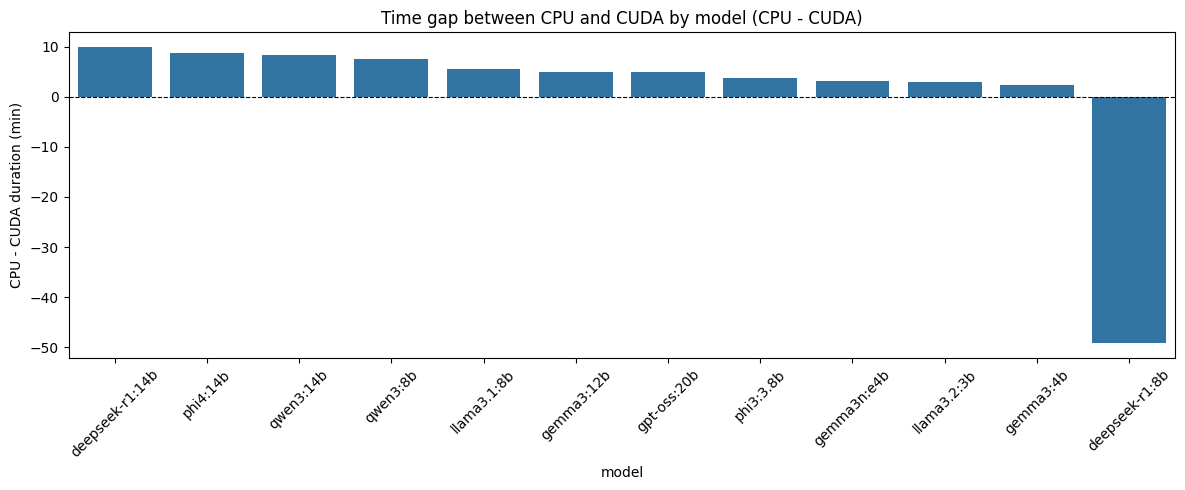

In [166]:
# time gap between CPU and CUDA (cpu_ms - cuda_ms)
pivot = df.groupby(['model', 'device'])['measured_duration_min'].mean().unstack()
if {'cpu', 'cuda'}.issubset(pivot.columns):
    # ensure no missing values and work on a copy
    pivot = pivot.reindex(pivot.index).fillna(0).copy()

    # reset index so 'model' becomes a column
    pivot = pivot.reset_index().rename(columns={'index': 'model'})

    # ensure numeric types and compute difference (values are already in minutes)
    pivot['cpu'] = pd.to_numeric(pivot['cpu'], errors='coerce').fillna(0)
    pivot['cuda'] = pd.to_numeric(pivot['cuda'], errors='coerce').fillna(0)
    pivot['cpu_minus_cuda_min'] = pivot['cpu'] - pivot['cuda']

    # build a 1-D list of model names ordered by the gap
    order = list(pivot.sort_values('cpu_minus_cuda_min', ascending=False)['model'])

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=pivot,
        x='model',
        y='cpu_minus_cuda_min',
        order=order
    )
    plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
    plt.xticks(rotation=45)
    plt.ylabel('CPU - CUDA duration (min)')
    plt.title('Time gap between CPU and CUDA by model (CPU - CUDA)')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute CPU vs CUDA gap (missing 'cpu' or 'cuda' device rows).")

#### Token per second gap

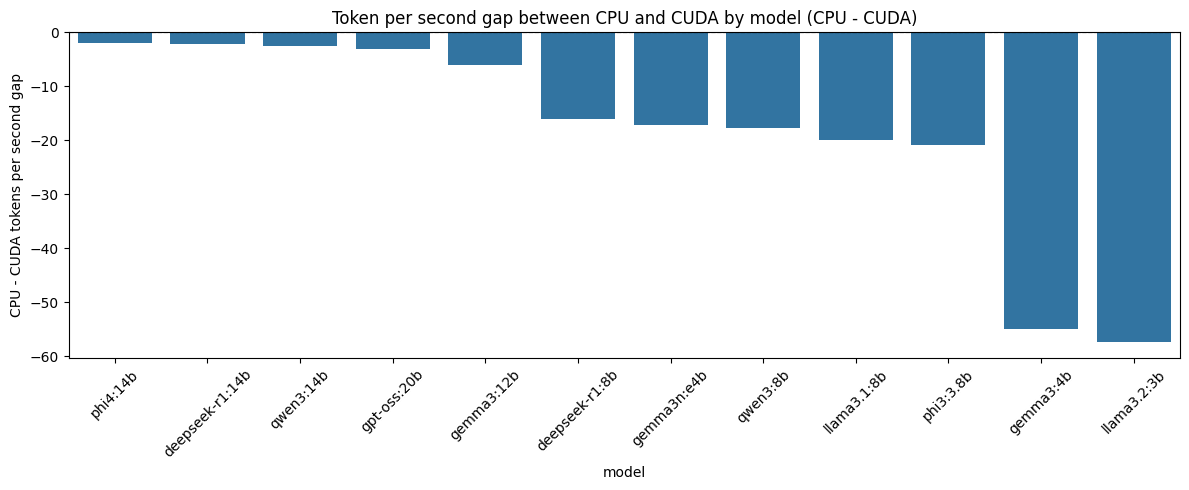

In [167]:
# time gap between CPU and CUDA (cpu_ms - cuda_ms)
pivot = df.groupby(['model', 'device'])['tokens_per_second'].mean().unstack()
if {'cpu', 'cuda'}.issubset(pivot.columns):
    # ensure no missing values and work on a copy
    pivot = pivot.reindex(pivot.index).fillna(0).copy()

    # reset index so 'model' becomes a column
    pivot = pivot.reset_index().rename(columns={'index': 'model'})

    # ensure numeric types and compute difference (values are already in minutes)
    pivot['cpu'] = pd.to_numeric(pivot['cpu'], errors='coerce').fillna(0)
    pivot['cuda'] = pd.to_numeric(pivot['cuda'], errors='coerce').fillna(0)
    pivot['cpu_minus_cuda_min'] = pivot['cpu'] - pivot['cuda']

    # build a 1-D list of model names ordered by the gap
    order = list(pivot.sort_values('cpu_minus_cuda_min', ascending=False)['model'])

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=pivot,
        x='model',
        y='cpu_minus_cuda_min',
        order=order
    )
    plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
    plt.xticks(rotation=45)
    plt.ylabel('CPU - CUDA tokens per second gap')
    plt.title('Token per second gap between CPU and CUDA by model (CPU - CUDA)')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute CPU vs CUDA gap (missing 'cpu' or 'cuda' device rows).")

In [168]:
df.groupby(['model', 'device'])['tokens_per_second'].mean().unstack()

device,cpu,cuda
model,,
deepseek-r1:14b,2.505725,4.599383
deepseek-r1:8b,4.150759,20.251961
gemma3:12b,3.343964,9.329835
gemma3:4b,9.405372,64.403980
gemma3n:e4b,8.177186,25.401282
gpt-oss:20b,5.440994,8.456999
llama3.1:8b,4.556869,24.461310
llama3.2:3b,8.779649,66.192878
phi3:3.8b,5.463181,26.340620


In [169]:

pivot_token = df.groupby(['model', 'device'])['tokens_per_second'].mean().unstack()
pivot_dur = df.groupby(['model', 'device'])['measured_duration_min'].mean().unstack()

# prepare a list of models to keep consistent ordering (try to reuse vc order if present)
models = list(vc.index) if 'vc' in globals() else sorted(df['model'].unique())

# build a safe summary even if one device is missing
def safe_gap(pivot, models):
    # ensure index contains all models and missing values filled with 0
    p = pivot.reindex(models).fillna(0).copy().reset_index().rename(columns={'index': 'model'})
    # coerce numeric and add cpu/cuda columns if missing
    p['cpu'] = pd.to_numeric(p.get('cpu', 0), errors='coerce').fillna(0)
    p['cuda'] = pd.to_numeric(p.get('cuda', 0), errors='coerce').fillna(0)
    return p

p_token = safe_gap(pivot_token, models)
p_dur = safe_gap(pivot_dur, models)

model_summary = pd.DataFrame({
    'model': p_token['model'],
    'gap_input_tokens': p_token['cpu'] - p_token['cuda'],
    # convert minutes gap to seconds
    'gap_total_duration_min': (p_dur['cpu'] - p_dur['cuda']),
})

# bubble size: proportional to number of samples per model (scaled for plotting)
counts = df.groupby('model').size().reindex(model_summary['model']).fillna(1)
model_summary['bubble_size'] = (counts / counts.max()) * 400 + 50

# ensure columns have expected dtypes
model_summary['gap_input_tokens'] = pd.to_numeric(model_summary['gap_input_tokens'], errors='coerce').fillna(0)
model_summary['gap_total_duration_min'] = pd.to_numeric(model_summary['gap_total_duration_min'], errors='coerce').fillna(0)

model_summary.head()


,model,gap_input_tokens,gap_total_duration_min,bubble_size
0,deepseek-r1:14b,-2.093658,9.915985,NaN
1,deepseek-r1:8b,-16.101202,-49.132288,NaN
2,gemma3:12b,-5.985871,4.986193,NaN
3,gemma3:4b,-54.998607,2.345463,NaN
4,gemma3n:e4b,-17.224096,3.211273,NaN


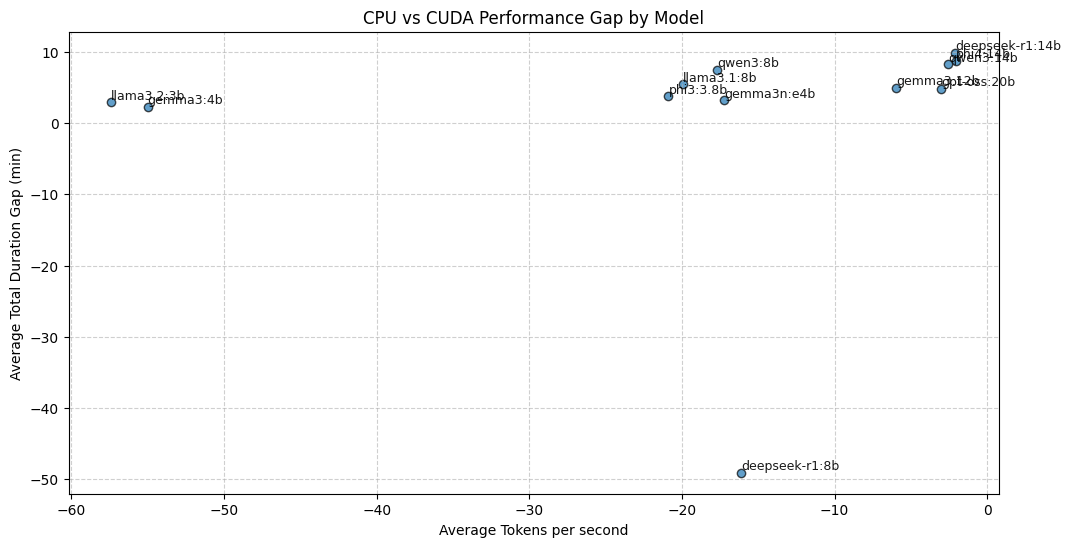

In [170]:

pivot_token = df.groupby(['model', 'device'])['tokens_per_second'].mean().unstack()
pivot_dur = df.groupby(['model', 'device'])['measured_duration_min'].mean().unstack()

# prepare a list of models to keep consistent ordering (try to reuse vc order if present)
models = list(vc.index) if 'vc' in globals() else sorted(df['model'].unique())

# build a safe summary even if one device is missing
def safe_gap(pivot, models):
    # ensure index contains all models and missing values filled with 0
    p = pivot.reindex(models).fillna(0).copy().reset_index().rename(columns={'index': 'model'})
    # coerce numeric and add cpu/cuda columns if missing
    p['cpu'] = pd.to_numeric(p.get('cpu', 0), errors='coerce').fillna(0)
    p['cuda'] = pd.to_numeric(p.get('cuda', 0), errors='coerce').fillna(0)
    return p

p_token = safe_gap(pivot_token, models)
p_dur = safe_gap(pivot_dur, models)

model_summary = pd.DataFrame({
    'model': p_token['model'],
    'gap_tokens': p_token['cpu'] - p_token['cuda'],
    # convert minutes gap to seconds
    'gap_total_duration_min': (p_dur['cpu'] - p_dur['cuda']),
})

# bubble size: proportional to number of samples per model (scaled for plotting)
counts = df.groupby('model').size().reindex(model_summary['model']).fillna(1)
model_summary['bubble_size'] = (counts / counts.max()) * 400 + 50

# ensure columns have expected dtypes
model_summary['gap_tokens'] = pd.to_numeric(model_summary['gap_tokens'], errors='coerce').fillna(0)
model_summary['gap_total_duration_min'] = pd.to_numeric(model_summary['gap_total_duration_min'], errors='coerce').fillna(0)

model_summary.head()


fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    model_summary["gap_tokens"],
    model_summary["gap_total_duration_min"],
    #s=model_summary["bubble_size"],
    alpha=0.7,
    color="#1f77b4",
    edgecolors="black",
)
for _, row in model_summary.iterrows():
    ax.text(
        row["gap_tokens"],
        row["gap_total_duration_min"],
        row["model"],
        fontsize=9,
        ha="left",
        va="bottom",
        alpha=0.9,
    )
ax.set_ylabel("Average Total Duration Gap (min)")
ax.set_xlabel("Average Tokens per second")
#ax.set_ylabel("Average Total Duration (s)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_title("CPU vs CUDA Performance Gap by Model")
plt.show()

In [171]:
def make_summary(df):
    pivot_token = df.groupby(['model', 'device'])['tokens_per_second'].mean().unstack()
    pivot_dur = df.groupby(['model', 'device'])['measured_duration_min'].mean().unstack()

    # prepare a list of models to keep consistent ordering
    models = sorted(df['model'].unique())

    # build a safe summary even if one device is missing
    def safe_gap(pivot, models):
        p = pivot.reindex(models).fillna(0).copy().reset_index().rename(columns={'index': 'model'})
        p['cpu'] = pd.to_numeric(p.get('cpu', 0), errors='coerce').fillna(0)
        p['cuda'] = pd.to_numeric(p.get('cuda', 0), errors='coerce').fillna(0)
        return p

    p_token = safe_gap(pivot_token, models)
    p_dur = safe_gap(pivot_dur, models)

    model_summary = pd.DataFrame({
        'model': p_token['model'],
        # CUDA - CPU gap for tokens per second
        'gap_tokens': p_token['cuda'] - p_token['cpu'],
        # CUDA - CPU gap for total duration (minutes)
        'gap_total_duration_min': p_dur['cuda'] - p_dur['cpu'],
    })

    # add parameter scale and bubble size
    model_summary['param_scale'] = model_summary['model'].apply(get_model_parameter_scale)
    model_summary['param_scale'] = pd.to_numeric(model_summary['param_scale'], errors='coerce').fillna(0)

    #counts = df.groupby('model').size().reindex(model_summary['model']).fillna(1)
    #model_summary['bubble_size'] = (counts / counts.max()) * 400 + 50

    # ensure numeric types and no NaNs
    model_summary['gap_tokens'] = pd.to_numeric(model_summary['gap_tokens'], errors='coerce').fillna(0)
    model_summary['gap_total_duration_min'] = pd.to_numeric(model_summary['gap_total_duration_min'], errors='coerce').fillna(0)

    return model_summary

model_summary = make_summary(df)
model_summary.head()

model_summary.head()

,model,gap_tokens,gap_total_duration_min,param_scale
0,deepseek-r1:14b,2.093658,-9.915985,14.0
1,deepseek-r1:8b,16.101202,49.132288,8.0
2,gemma3:12b,5.985871,-4.986193,12.0
3,gemma3:4b,54.998607,-2.345463,4.0
4,gemma3n:e4b,17.224096,-3.211273,4.0


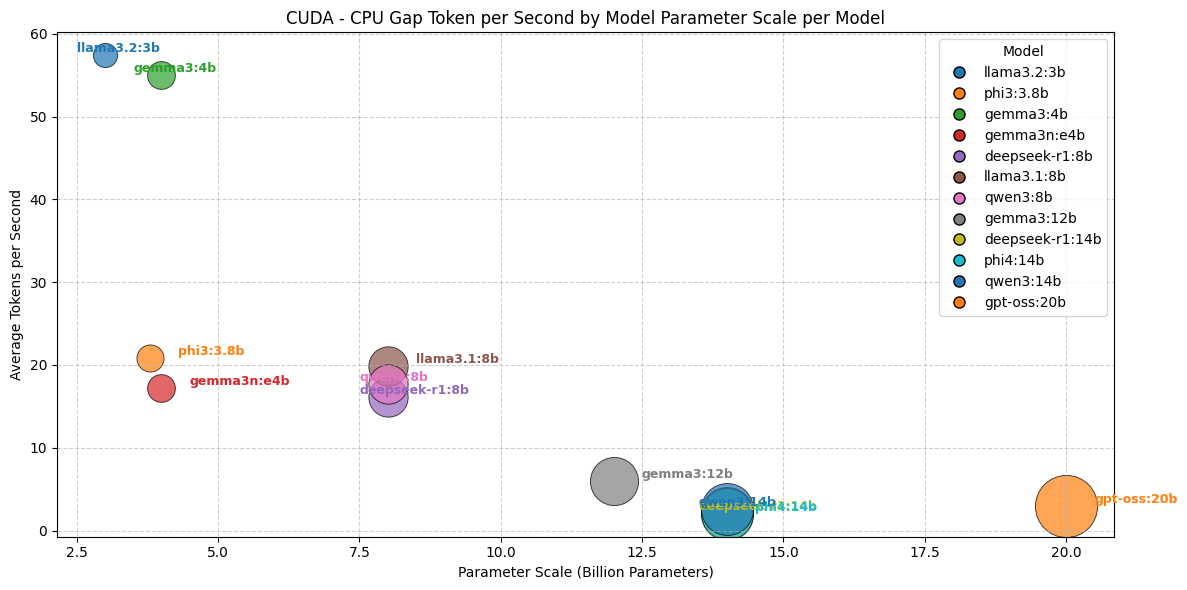

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

# generate a unique color per model
palette = sns.color_palette( n_colors=len(model_summary))
model_summary.sort_values("param_scale", inplace=True)
model_colors = dict(zip(model_summary["model"], palette))

fig, ax = plt.subplots(figsize=(12, 6))
i = 1
# plot bubbles with model-specific colors
for _, row in model_summary.iterrows():
    color = model_colors[row["model"]]
    ax.scatter(
        
        row["param_scale"], #row["gap_total_duration_min"],
        row["gap_tokens"],
        s=row["param_scale"] * 100,
        alpha=0.7,
        color=color,
        edgecolors="black",
        linewidth=0.7,
    )
    ax.text(
        row["param_scale"] + (0.5*(-1)**i), #row["gap_total_duration_min"]
        row["gap_tokens"],
        row["model"],
        fontsize=9,
        ha="left",
        va="bottom",
        alpha=1,
        fontweight='bold',
        color=color,
    )
    i += 1
    
    # add a label for the bubble size

ax.set_ylabel("Average Tokens per Second")
ax.set_xlabel("Parameter Scale (Billion Parameters)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_title("CUDA - CPU Gap Token per Second by Model Parameter Scale per Model")

# optional legend showing color per model
handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=model,
               markerfacecolor=color, markersize=8, markeredgecolor="black")
    for model, color in model_colors.items()
]
ax.legend(handles=handles, title="Model", loc="best")

plt.tight_layout()
plt.show()


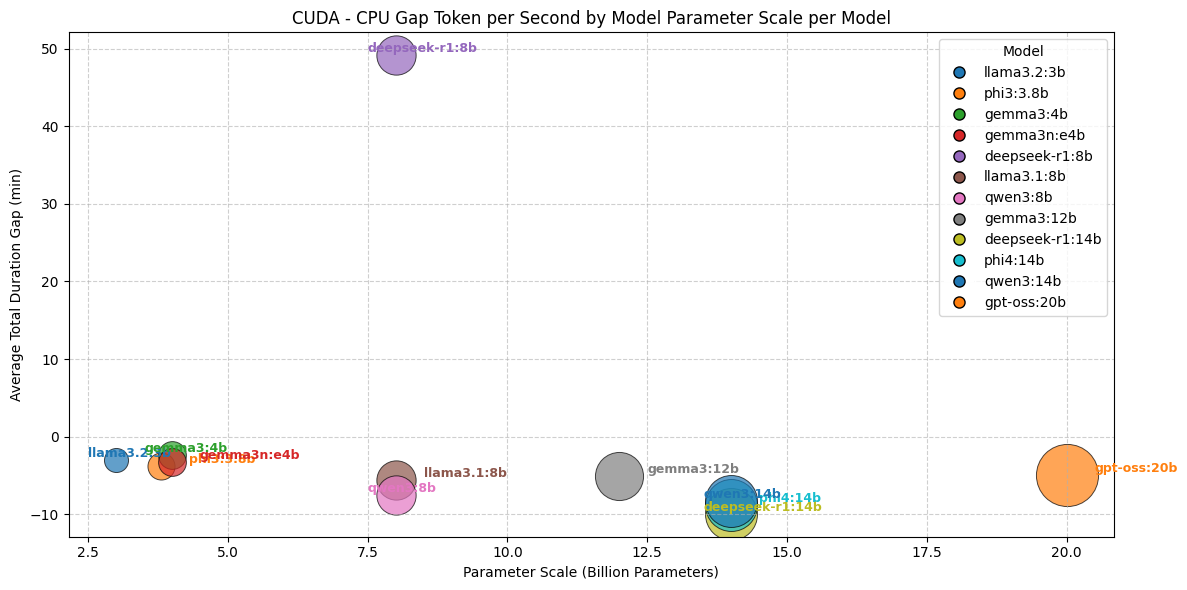

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# generate a unique color per model
palette = sns.color_palette( n_colors=len(model_summary))
model_summary.sort_values("param_scale", inplace=True)
model_colors = dict(zip(model_summary["model"], palette))

fig, ax = plt.subplots(figsize=(12, 6),dpi = 100)
i = 1
# plot bubbles with model-specific colors
for _, row in model_summary.iterrows():
    color = model_colors[row["model"]]
    ax.scatter(
        
        row["param_scale"], #row["gap_total_duration_min"],
        row["gap_total_duration_min"],
        s=row["param_scale"] * 100,
        alpha=0.7,
        color=color,
        edgecolors="black",
        linewidth=0.7,
    )
    ax.text(
        row["param_scale"] + (0.5*(-1)**i), #row["gap_total_duration_min"]
        row["gap_total_duration_min"],
        row["model"],
        fontsize=9,
        ha="left",
        va="bottom",
        alpha=1,
        fontweight='bold',
        color=color,
    )
    i += 1
    
    # add a label for the bubble size

ax.set_ylabel("Average Total Duration Gap (min)")
ax.set_xlabel("Parameter Scale (Billion Parameters)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_title("CUDA - CPU Gap Token per Second by Model Parameter Scale per Model")

# optional legend showing color per model
handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=model,
               markerfacecolor=color, markersize=8, markeredgecolor="black")
    for model, color in model_colors.items()
]
ax.legend(handles=handles, title="Model", loc="best")

plt.tight_layout()
plt.show()


In [174]:
(df.iloc[0].output_tokens / df.iloc[0].output_duration_ms)*1000 # it is tokens_per_second

13.310436398018629

In [175]:
from aymurai.utils.json_data import load_json, save_json

save_json(summaries,DATA_PATH + "summaries.json", )

In [176]:
df.iloc[0].input_duration_ms + df.iloc[0].output_duration_ms   # total duration in ms

54407.301494

## Qualitative Analysis

### Garbage Detection - Outliers 

In [177]:
df.describe()

,input_tokens,input_duration_ms,output_tokens,output_duration_ms,total_tokens,model_duration_ms,measured_duration_ms,tokens_per_second,input_duration_min,output_duration_min,model_duration_min,measured_duration_min
count,648.000000,6.480000e+02,648.000000,6.480000e+02,648.000000,6.480000e+02,6.480000e+02,648.000000,648.000000,648.000000,648.000000,648.000000
mean,7083.725309,1.679399e+05,3483.907407,4.740451e+05,10567.632716,6.504260e+05,6.504340e+05,14.255853,2.798999,7.900752,10.840433,10.840567
std,5220.735846,2.572814e+05,20175.381094,2.707865e+06,21111.693751,2.719057e+06,2.719062e+06,19.054841,4.288023,45.131076,45.317622,45.317705
min,657.000000,1.885951e+02,41.000000,1.854566e+03,772.000000,4.557130e+03,4.559146e+03,1.798987,0.003143,0.030909,0.075952,0.075986
25%,1482.000000,1.168172e+04,470.500000,4.209265e+04,2502.750000,7.223706e+04,7.223994e+04,3.533236,0.194695,0.701544,1.203951,1.203999
50%,7276.500000,5.039702e+04,734.000000,1.161064e+05,7967.000000,2.123932e+05,2.123952e+05,7.197120,0.839950,1.935107,3.539887,3.539920
75%,10350.500000,2.356869e+05,1123.000000,2.407821e+05,11870.250000,4.635547e+05,4.635576e+05,11.711153,3.928114,4.013035,7.725911,7.725960
max,16384.000000,1.725763e+06,163840.000000,5.035604e+07,180002.000000,5.040554e+07,5.040555e+07,92.801712,28.762716,839.267302,840.092394,840.092553


max output_tokens is 163840, same value as max input token, so, it is truncated. We will see examples

In [178]:
df_truncated = df[df['output_tokens']>16000]
print('Truncated summary analysis: \ndoc paths: \n',df_truncated.doc_path.unique())
print('Models: \n',df_truncated.model.unique())
df_truncated.head()

Truncated summary analysis: 
doc paths: 
 ['1- FLORES ABARCA, Francisco Alexander s 149 bis J-01-00369422-0-2022-1 Sala Feria (II) nnya vict do apela pp.pdf'
 'Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 NNAPES inadmisible RI AT x prision domiciliaira rechazada .pdf'
 'aymurai - ejemplo 03.docx'
 '01 - NN x 5C - condenada ROJAS Daniana Micaela - prision domiciliaria - copia.pdf'
 'Abr. 26 - Perez Diego Javier x 149 bis CP - Inadmisible RI ATC.pdf'
 '2 - Feb. 2 - DE ON, Kwan x 13944.pdf'
 '2 - FISSCHER Alejandro Claudio s - 92.pdf']
Models: 
 ['deepseek-r1:8b' 'phi3:3.8b']


,model,options,system_prompt,user_prompt,chat_response,input_tokens,input_duration_ms,output_tokens,output_duration_ms,total_tokens,...,measured_duration_ms,tokens_per_second,raw_response,doc_path,device,system_prompt_type,input_duration_min,output_duration_min,model_duration_min,measured_duration_min
27,deepseek-r1:8b,{'num_ctx': 16384},Eres un asistente especializado en resumir doc...,CUIJ J-01-00369422-0/2022-1 EXP. MPT 13904/202...,"<think>\nFirst, el usuario\nOkay, analizo el d...",7615,51740.229488,163840,1.667185e+07,171455,...,1.674161e+07,9.827341,"{'model': 'deepseek-r1:8b', 'created_at': '202...","1- FLORES ABARCA, Francisco Alexander s 149 bi...",cuda,baseline,0.862337,277.864245,279.026692,279.026896
59,deepseek-r1:8b,{'num_ctx': 16384},Eres un asistente especializado en resumir doc...,"CÁMARA DE CASACIÓN Y APELACIONES EN LO PENAL, ...","<think>\nOkay, primero, analizaré el texto pro...",4700,28581.478687,163840,1.657151e+07,168540,...,1.661818e+07,9.886847,"{'model': 'deepseek-r1:8b', 'created_at': '202...",Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 ...,cuda,baseline,0.476358,276.191855,276.969538,276.969734
60,deepseek-r1:8b,{'num_ctx': 16384},Eres un analista legal especializado en elabor...,"CÁMARA DE CASACIÓN Y APELACIONES EN LO PENAL, ...","<think>\nOkay, vamos a empezamos a analizar el...",4731,27648.626376,163840,1.653484e+07,168571,...,1.656262e+07,9.908775,"{'model': 'deepseek-r1:8b', 'created_at': '202...",Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 ...,cuda,task-specific,0.460810,275.580651,276.043560,276.043746
190,deepseek-r1:8b,"{'': 8192, 'top_k': 1, 'temperature': 0.0}",Eres un analista legal especializado en elabor...,JUZGADO DE FAMILIA N.o 2 DE LA CIUDAD DE PUERT...,<think>\nPrimero\nVamos los he recibido el tex...,1234,1254.386415,40960,1.052336e+06,42194,...,1.053712e+06,38.922922,"{'model': 'deepseek-r1:8b', 'created_at': '202...",aymurai - ejemplo 03.docx,cuda,task-specific,0.020906,17.538937,17.561801,17.561864
222,phi3:3.8b,{'num_ctx': 16384},Eres un asistente especializado en resumir doc...,CUIJ J-01-00101241-6/2024-1 EXP. MPT 13847/202...,"En el caso de Daiana Rojas, se le condenó a cu...",8363,15051.051427,16214,2.440389e+06,24577,...,2.463501e+06,6.644022,"{'model': 'phi3:3.8b', 'created_at': '2025-10-...",01 - NN x 5C - condenada ROJAS Daniana Micaela...,cuda,baseline,0.250851,40.673154,41.058295,41.058343


In [179]:
df_truncated.groupby(['model','doc_path','system_prompt_type']).count()

options  \
model          doc_path                                           system_prompt_type            
deepseek-r1:8b 01 - NN x 5C - condenada ROJAS Daniana Micaela ... task-specific             1   
                                                                  template                  1   
               1- FLORES ABARCA, Francisco Alexander s 149 bis... baseline                  1   
               2 - FISSCHER Alejandro Claudio s - 92.pdf          baseline                  1   
                                                                  task-specific             1   
               2 - Feb. 2 - DE ON, Kwan x 13944.pdf               template                  1   
               Abr. 26 - Perez Diego Javier x 149 bis CP - Ina... template                  1   
               Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 N... baseline                  1   
                                                                  task-specific             1   
               aymurai - ejemplo 03.docx                          task-specific             1   
                                                                  template                  1   
phi3:3.8b      01 - NN x 5C - condenada ROJAS Daniana Micaela ... baseline                  1   

                                                                                      system_prompt  \
model          doc_path                                           system_prompt_type                  
deepseek-r1:8b 01 - NN x 5C - condenada ROJAS Daniana Micaela ... task-specific                   1   
                                                                  template                        1   
               1- FLORES ABARCA, Francisco Alexander s 149 bis... baseline                        1   
               2 - FISSCHER Alejandro Claudio s - 92.pdf          baseline                        1   
                                                                  task-specific                   1   
               2 - Feb. 2 - DE ON, Kwan x 13944.pdf               template                        1   
               Abr. 26 - Perez Diego Javier x 149 bis CP - Ina... template                        1   
               Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 N... baseline                        1   
                                                                  task-specific                   1   
               aymurai - ejemplo 03.docx                          task-specific                   1   
                                                                  template                        1   
phi3:3.8b      01 - NN x 5C - condenada ROJAS Daniana Micaela ... baseline                        1   

                                                                                      user_prompt  \
model          doc_path                                           system_prompt_type                
deepseek-r1:8b 01 - NN x 5C - condenada ROJAS Daniana Micaela ... task-specific                 1   
                                                                  template                      1   
               1- FLORES ABARCA, Francisco Alexander s 149 bis... baseline                      1   
               2 - FISSCHER Alejandro Claudio s - 92.pdf          baseline                      1   
                                                                  task-specific                 1   
               2 - Feb. 2 - DE ON, Kwan x 13944.pdf               template                      1   
               Abr. 26 - Perez Diego Javier x 149 bis CP - Ina... template                      1   
               Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 N... baseline                      1   
                                                                  task-specific                 1   
               aymurai - ejemplo 03.docx                          task-specific                 1   
                                                                  templa

11 of 12 outputs truncated correspond to deepseek-r1:8b model, and the other one to phi3:3.8b. We will see the hallucinations bellow

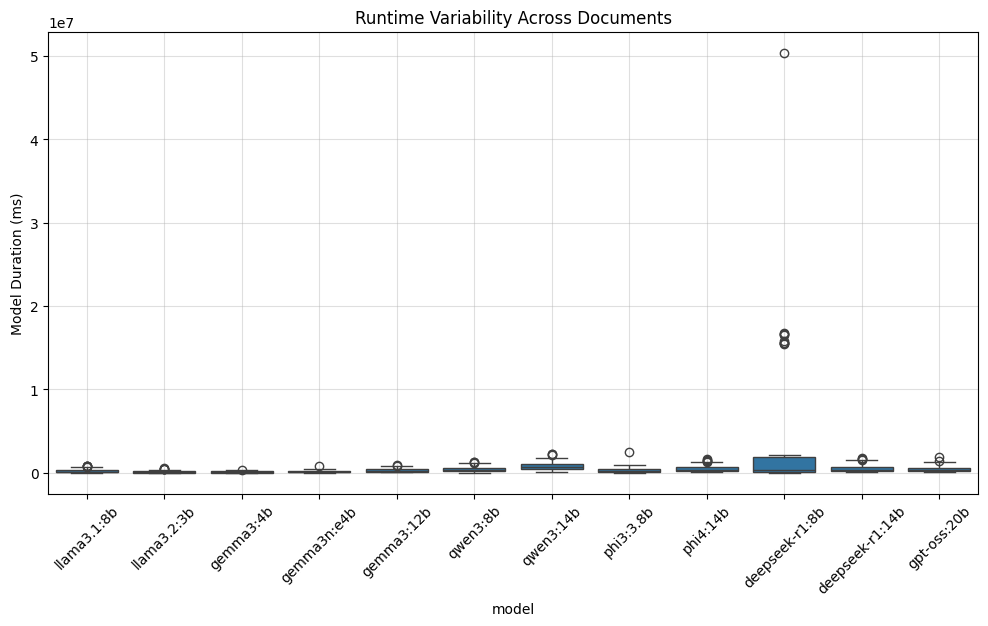

In [180]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='model', y='model_duration_ms')
plt.xticks(rotation=45)
plt.title("Runtime Variability Across Documents")
plt.ylabel("Model Duration (ms)")
plt.grid(True, alpha=0.4)
plt.show()


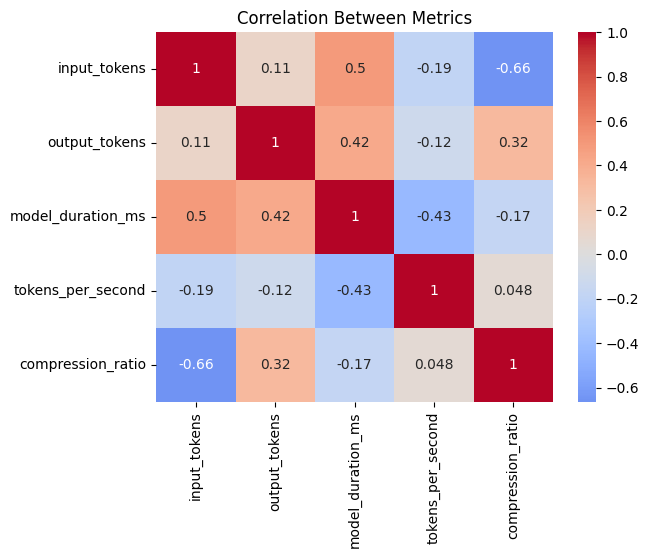

In [182]:
corr = df_to_plot[['input_tokens','output_tokens','model_duration_ms','tokens_per_second','compression_ratio']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Between Metrics")
plt.show()


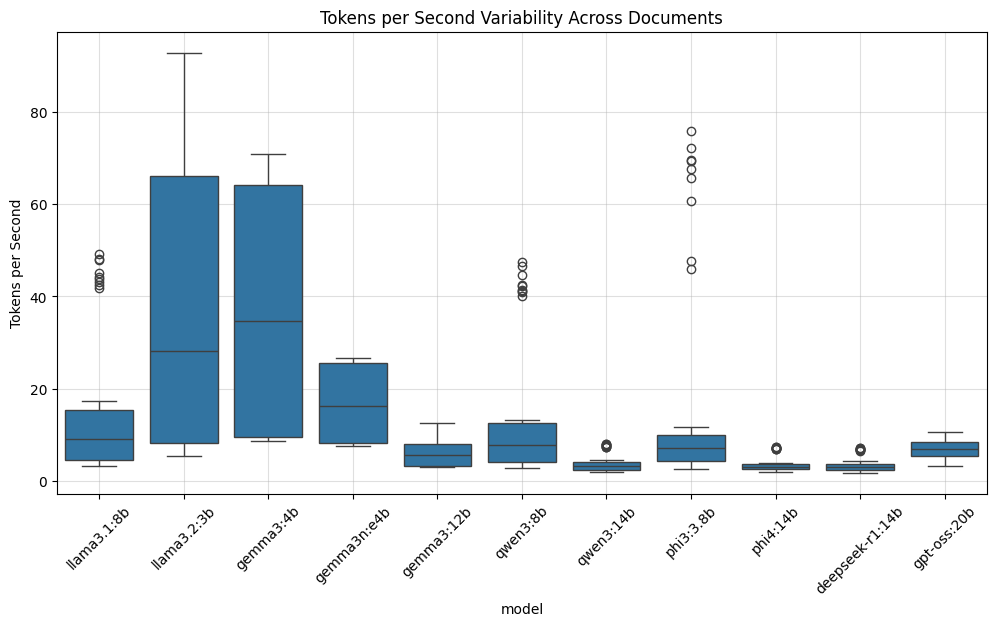

In [183]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_to_plot, x='model', y='tokens_per_second')
plt.xticks(rotation=45)
plt.title("Tokens per Second Variability Across Documents")
plt.ylabel("Tokens per Second")
plt.grid(True, alpha=0.4)
plt.show()


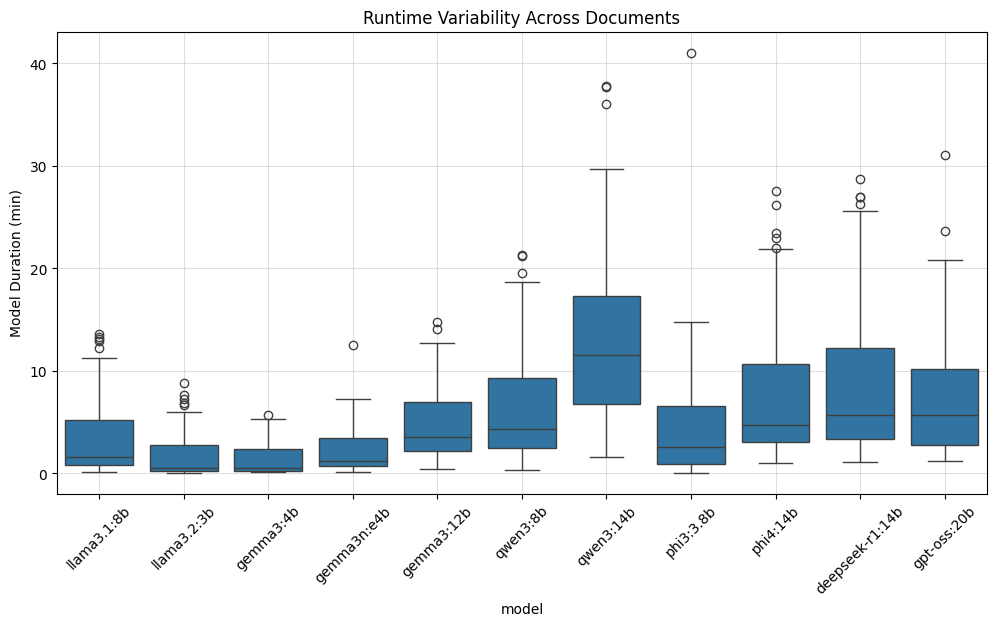

In [193]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_to_plot, x='model', y='model_duration_min')
plt.xticks(rotation=45)
plt.title("Runtime Variability Across Documents")
plt.ylabel("Model Duration (min)")
plt.grid(True, alpha=0.4)
plt.show()


### Analysis by document

/var/folders/yf/2cttyjmx5j35yhq4st33mdmm0000gn/T/ipykernel_20340/4251473321.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


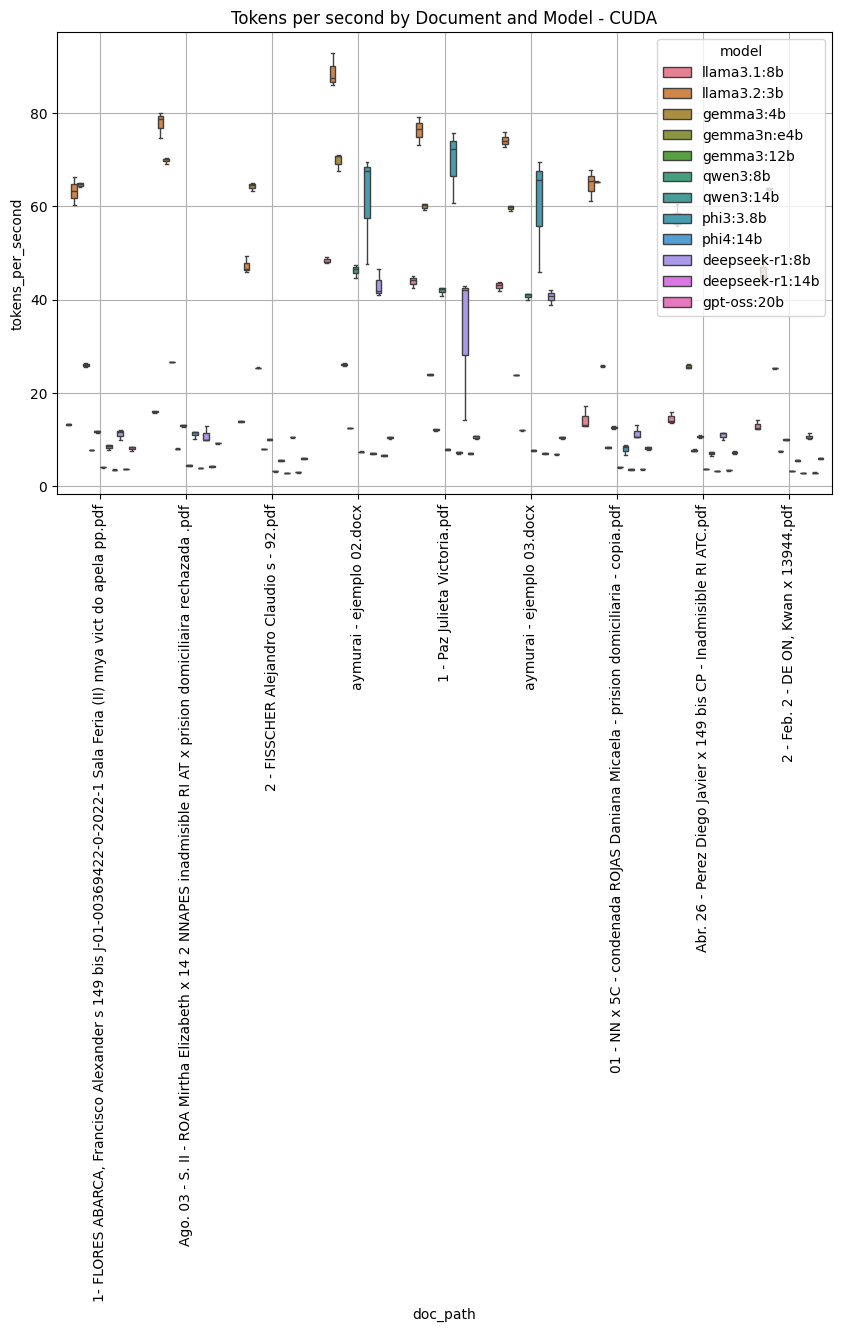

In [185]:
df_cuda = df[df['device']=='cuda']
plt.figure(figsize=(10,6))
sns.boxplot(data=df_cuda, x='doc_path', y='tokens_per_second', hue='model')
plt.xticks(rotation=90)
plt.title("Tokens per second by Document and Model - CUDA")
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/yf/2cttyjmx5j35yhq4st33mdmm0000gn/T/ipykernel_20340/123695987.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


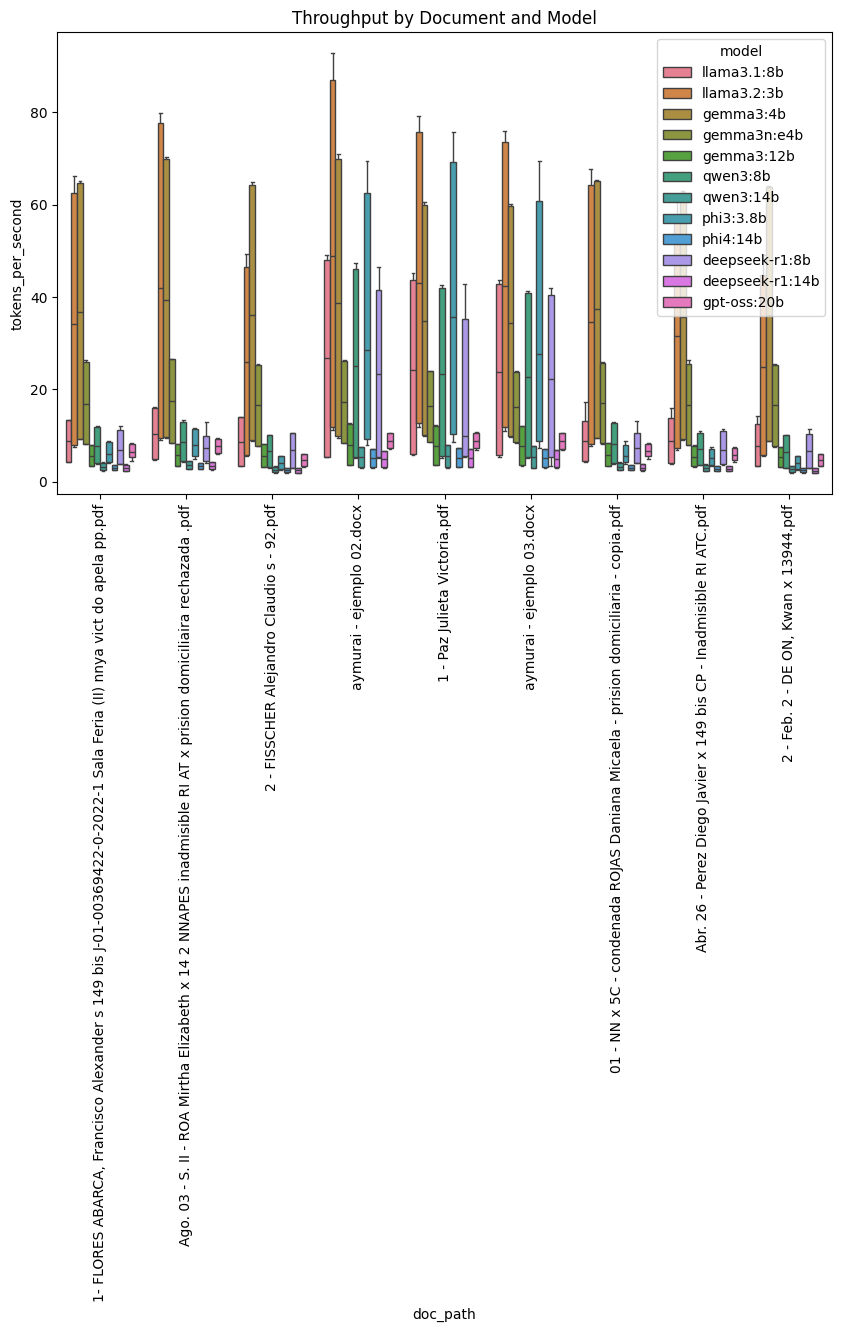

In [186]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='doc_path', y='tokens_per_second', hue='model')
plt.xticks(rotation=90)
plt.title("Throughput by Document and Model")
plt.tight_layout()
plt.show()


In [196]:
order = sorted(df['model'].unique())
order

['deepseek-r1:14b',
 'deepseek-r1:8b',
 'gemma3:12b',
 'gemma3:4b',
 'gemma3n:e4b',
 'gpt-oss:20b',
 'llama3.1:8b',
 'llama3.2:3b',
 'phi3:3.8b',
 'phi4:14b',
 'qwen3:14b',
 'qwen3:8b']

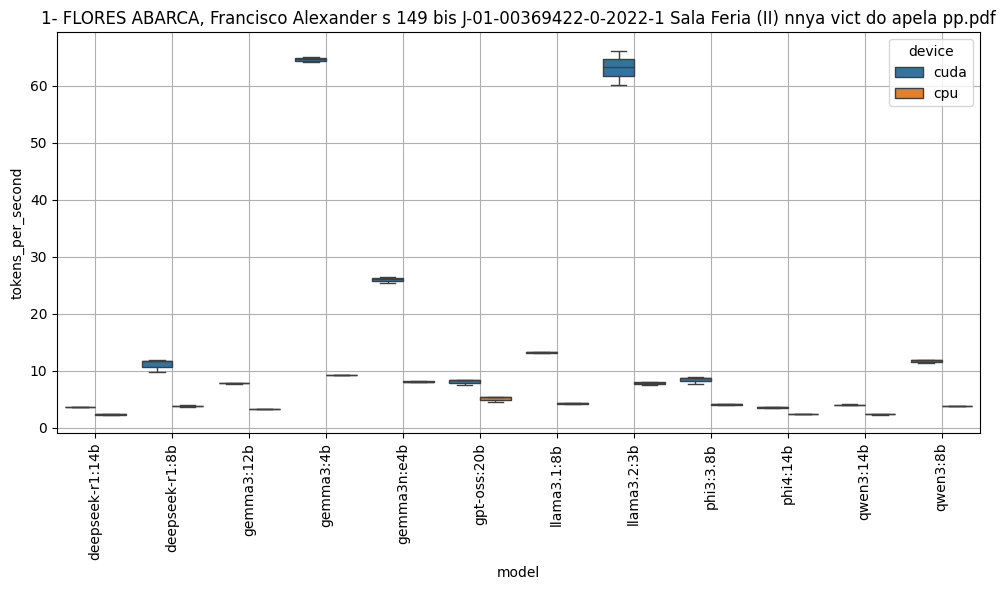

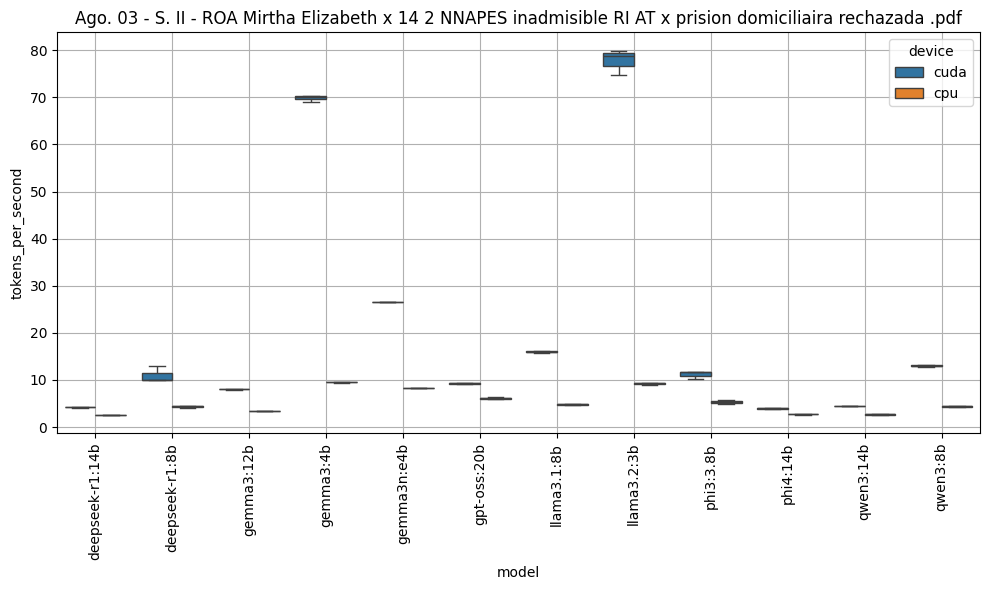

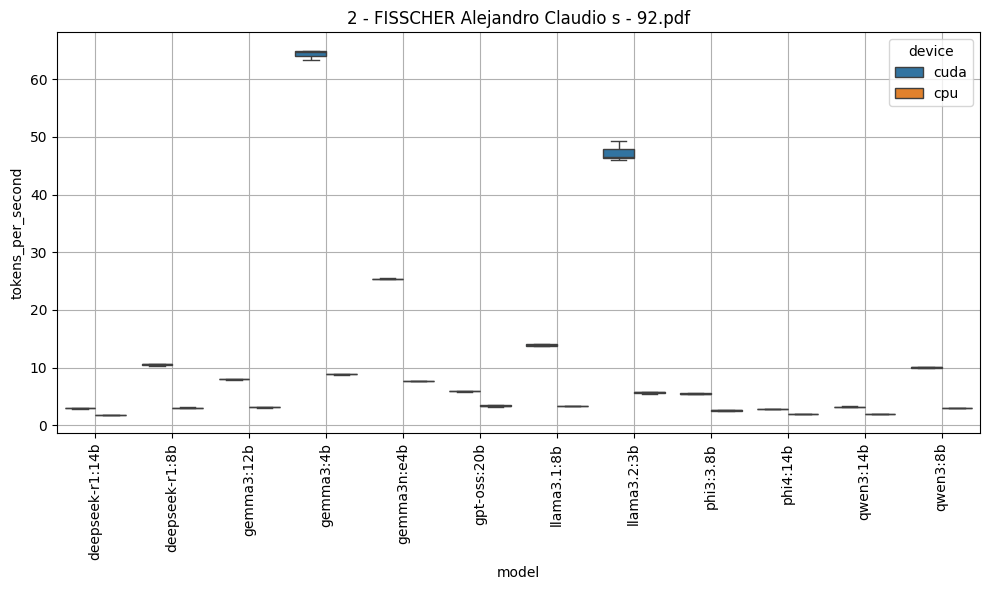

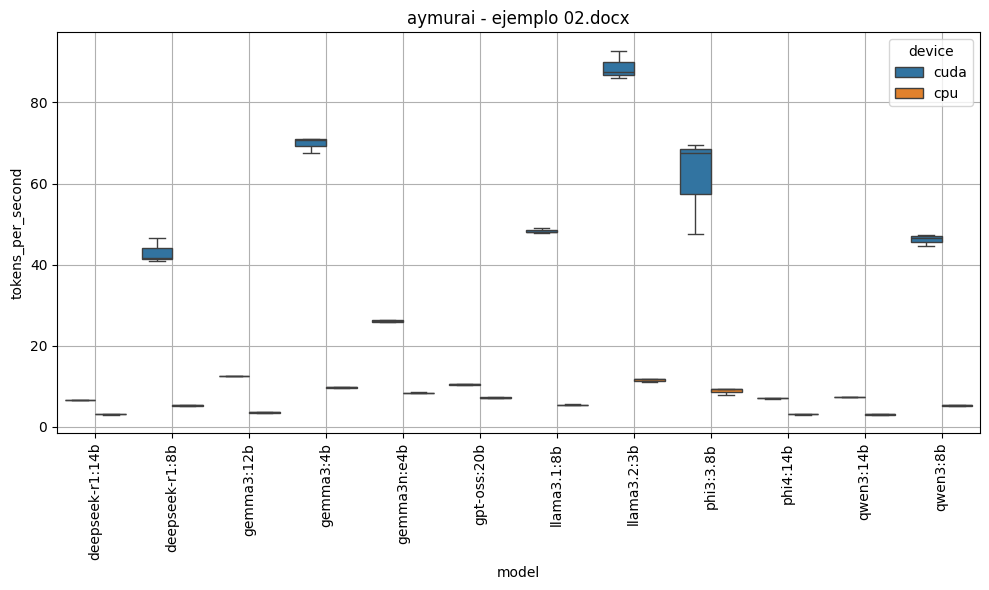

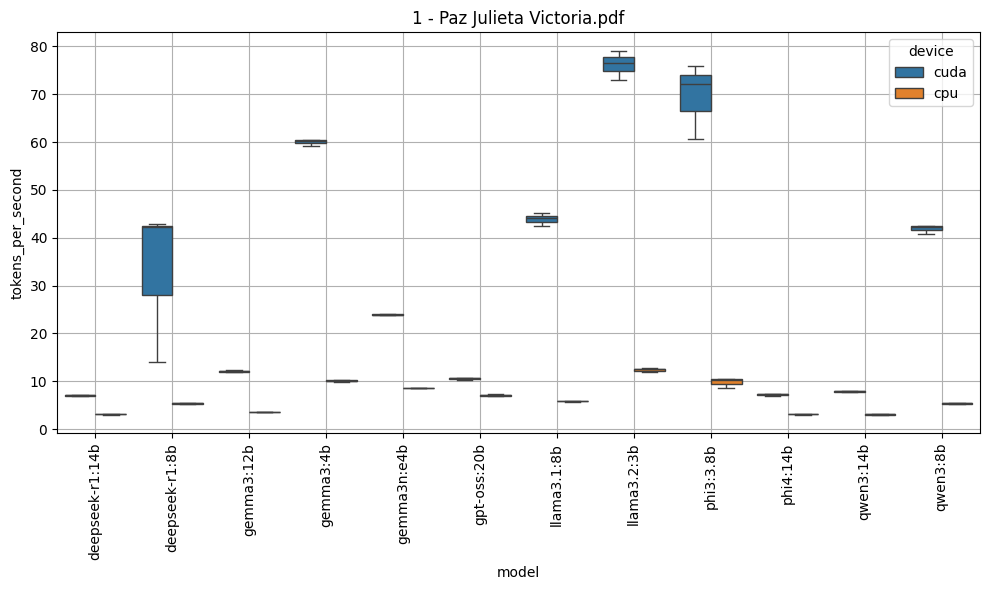

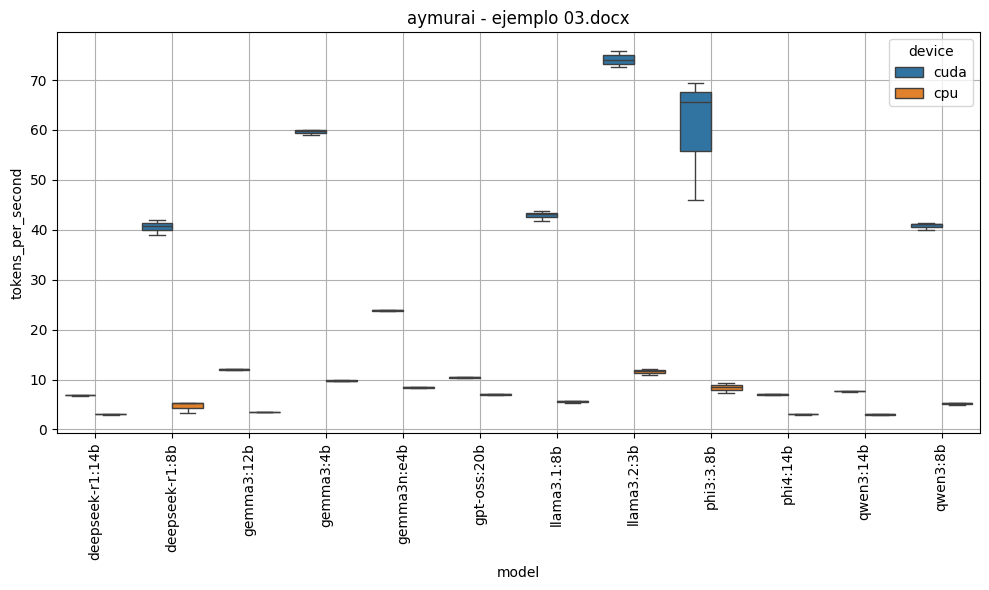

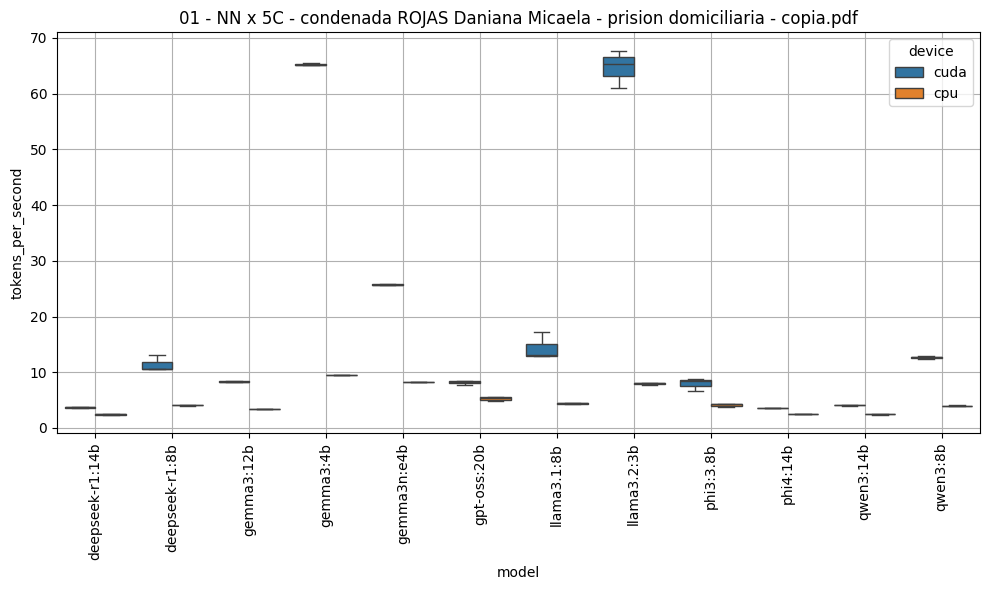

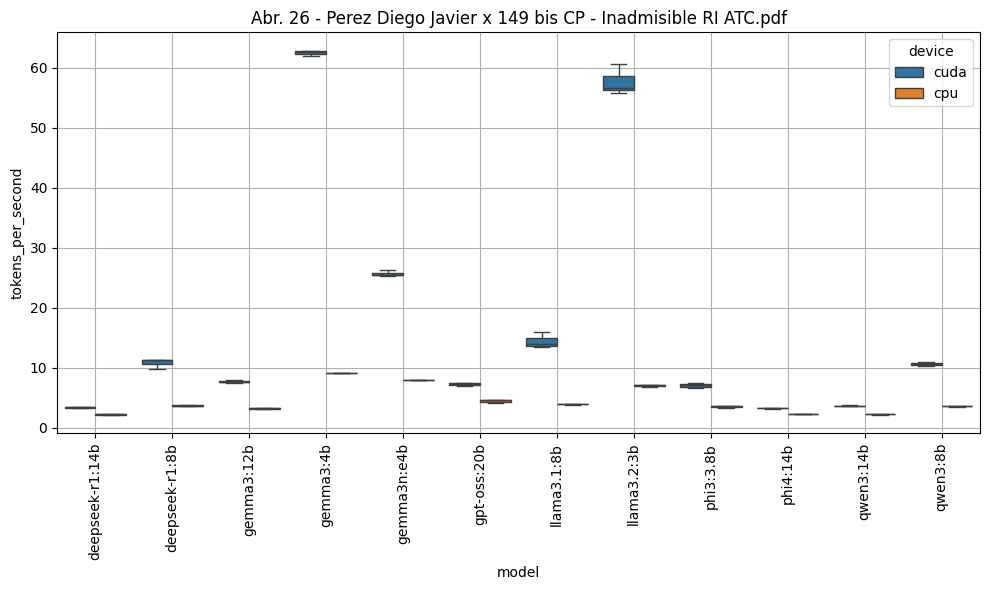

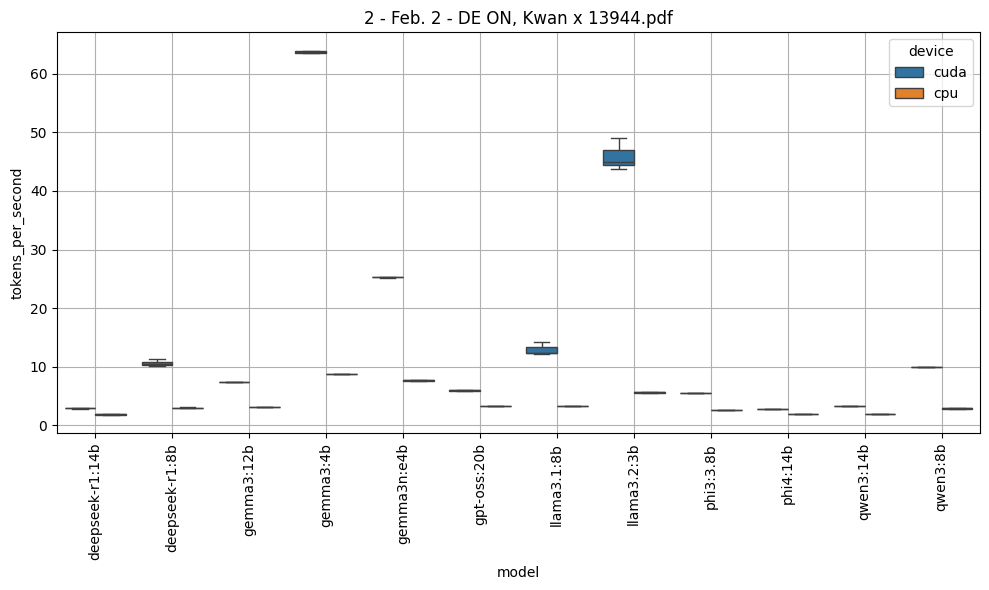

In [198]:
for doc in df['doc_path'].unique():
    df_doc = df[df['doc_path'] == doc]
    doc_name = doc.split('/')[-1]
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_doc, x='model', y='tokens_per_second', hue='device', order=order)
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.title(f"{doc_name}")
    plt.tight_layout()
    plt.show()

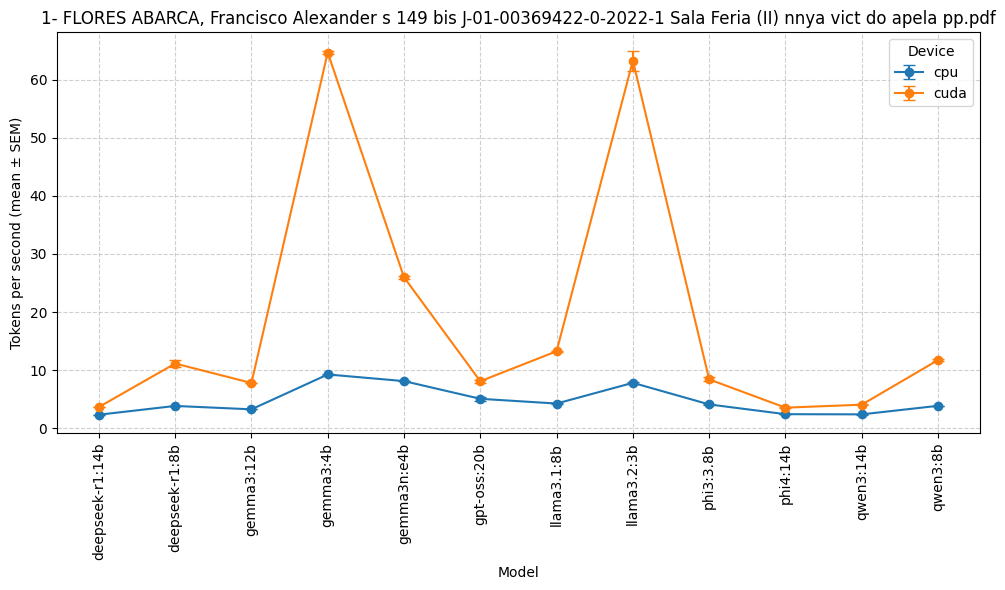

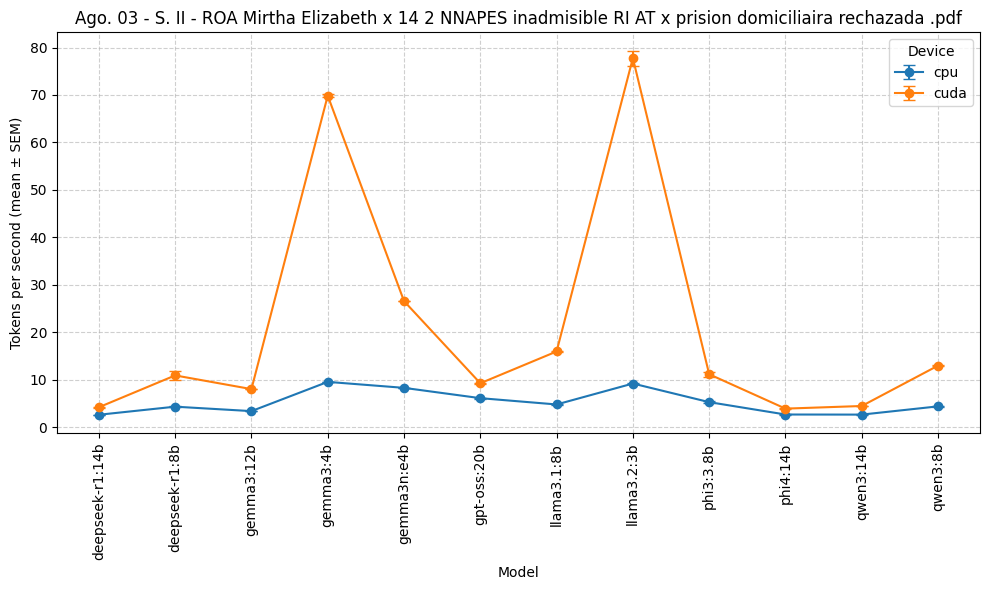

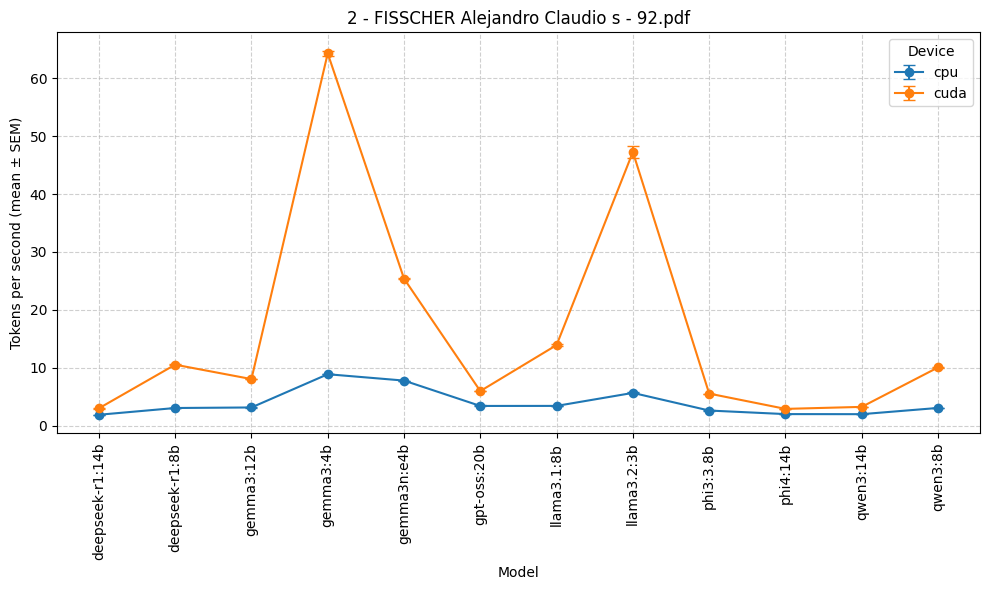

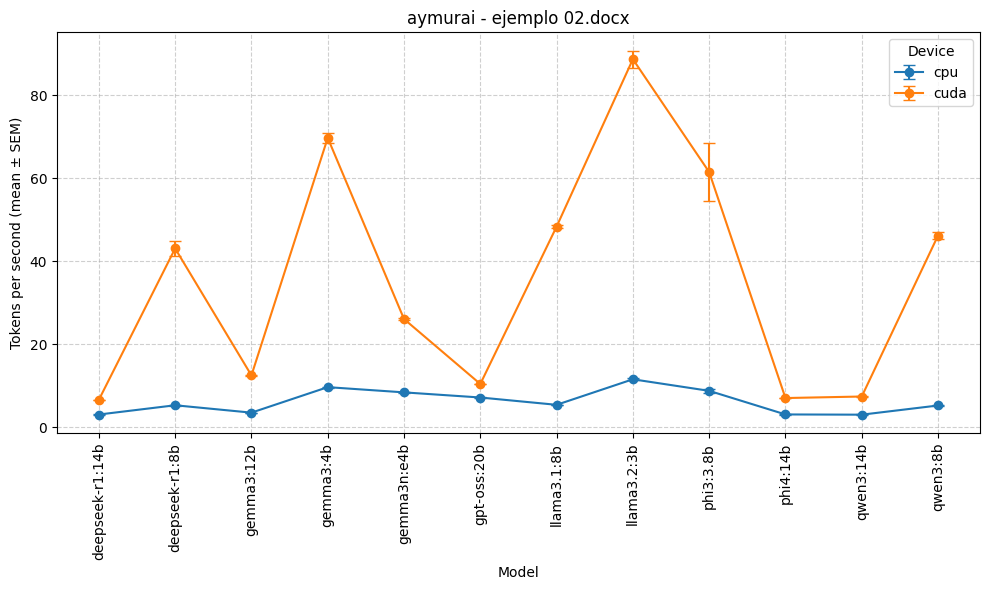

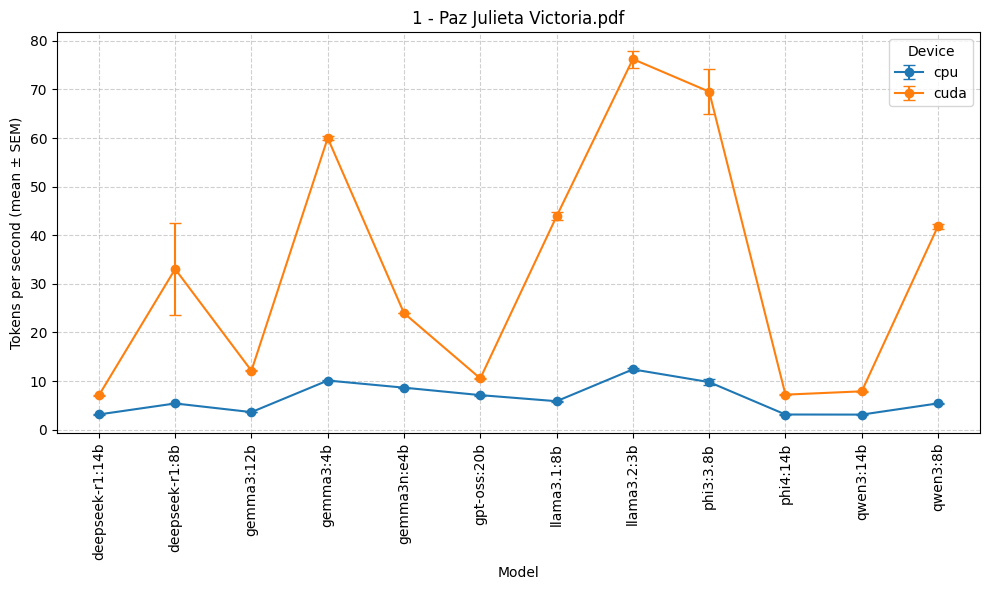

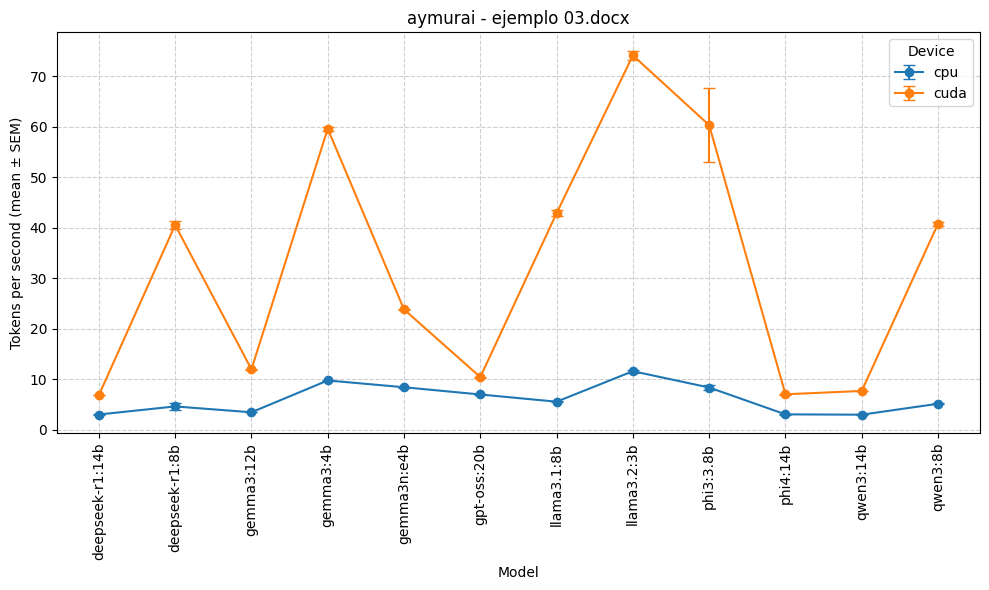

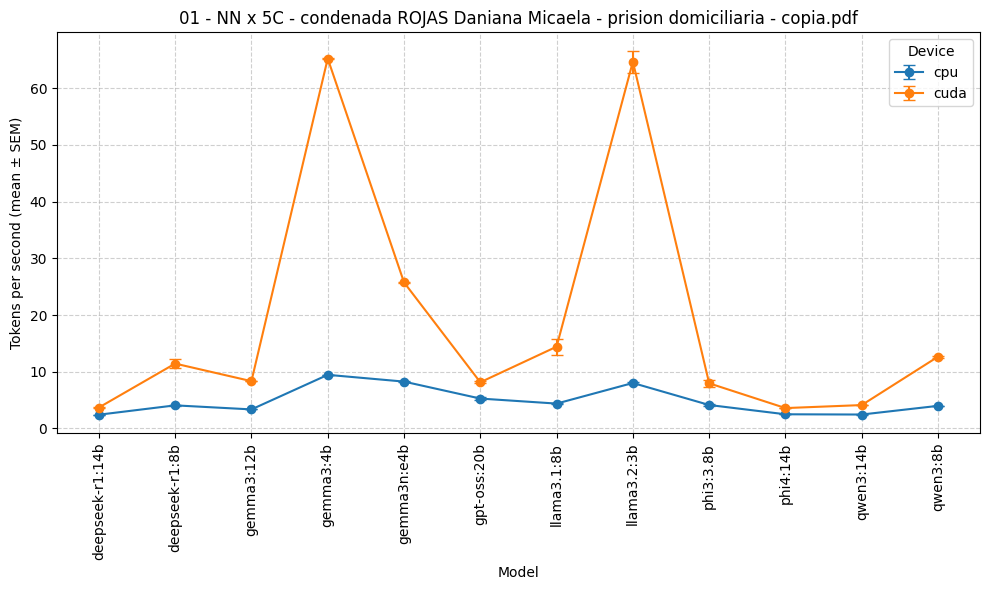

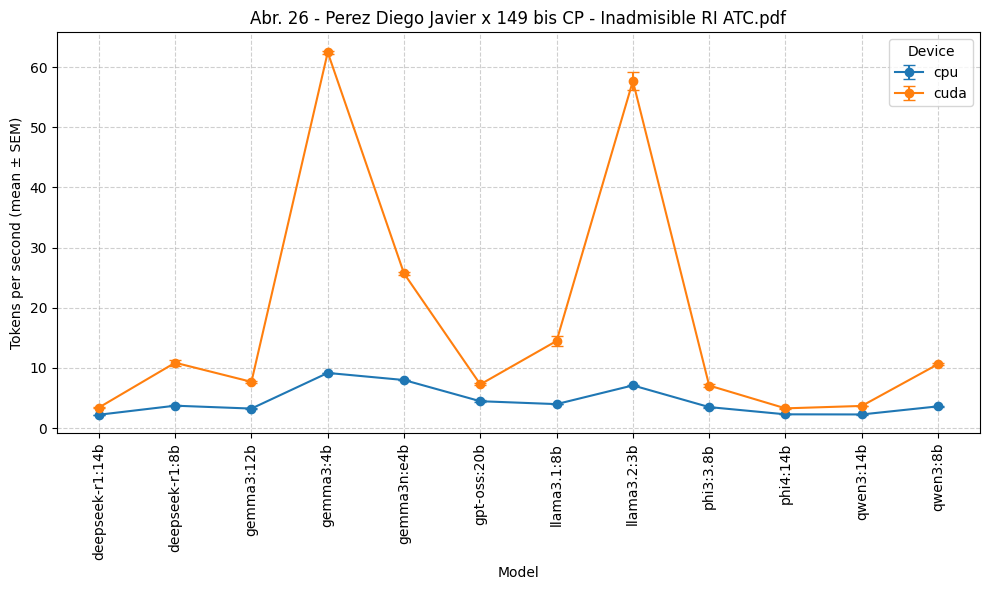

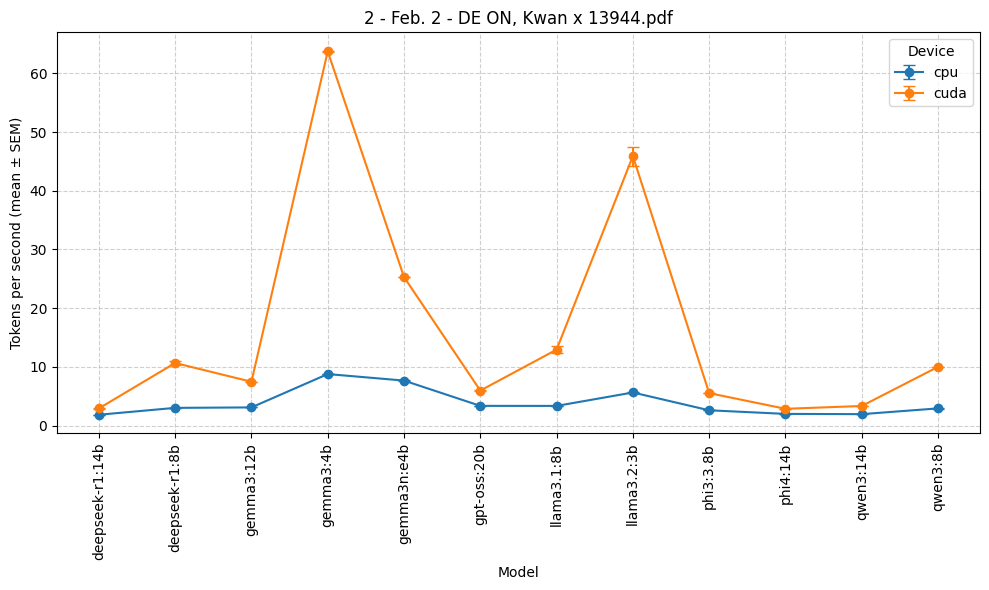

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# assuming df has columns: ['doc_path', 'model', 'tokens_per_second', 'device']

for doc in df['doc_path'].unique():
    df_doc = df[df['doc_path'] == doc]
    doc_name = doc.split('/')[-1]
    
    # Compute mean and std per model/device
    df_summary = (
        df_doc.groupby(['model', 'device'])['tokens_per_second']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    df_summary['sem'] = df_summary['std'] / df_summary['count']**0.5  # standard error

    # Sort models for consistent order
    order = sorted(df_summary['model'].unique())
    
    plt.figure(figsize=(10,6))
    
    # Plot one line per device
    for device, df_dev in df_summary.groupby('device'):
        plt.errorbar(
            df_dev['model'], df_dev['mean'],
            yerr=df_dev['sem'], fmt='-o',
            capsize=4, label=device
        )
    
    plt.xticks(rotation=90)
    plt.xlabel("Model")
    plt.ylabel("Tokens per second (mean ± SEM)")
    plt.title(f"{doc_name}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Device")
    plt.tight_layout()
    plt.show()


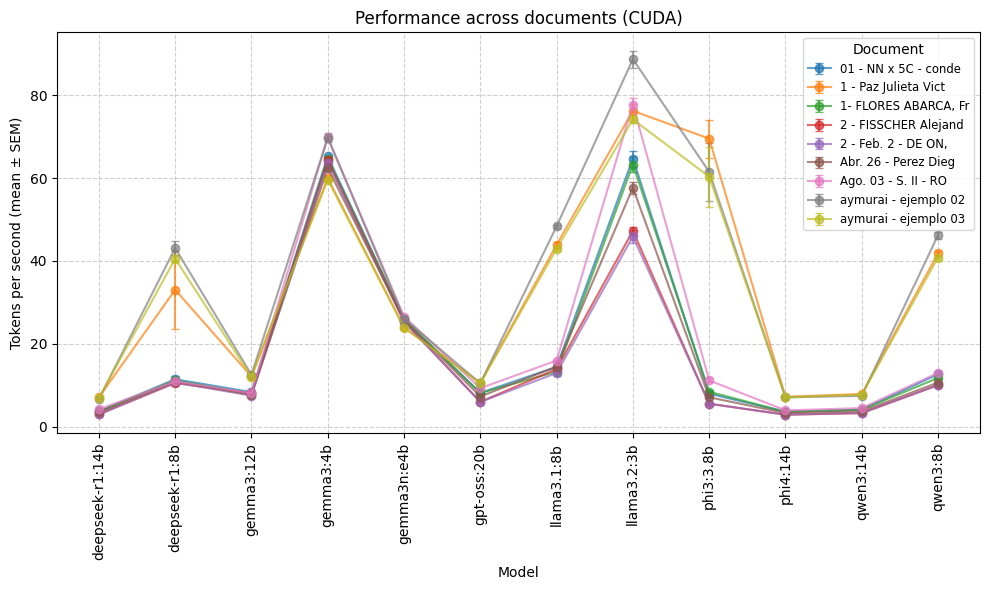

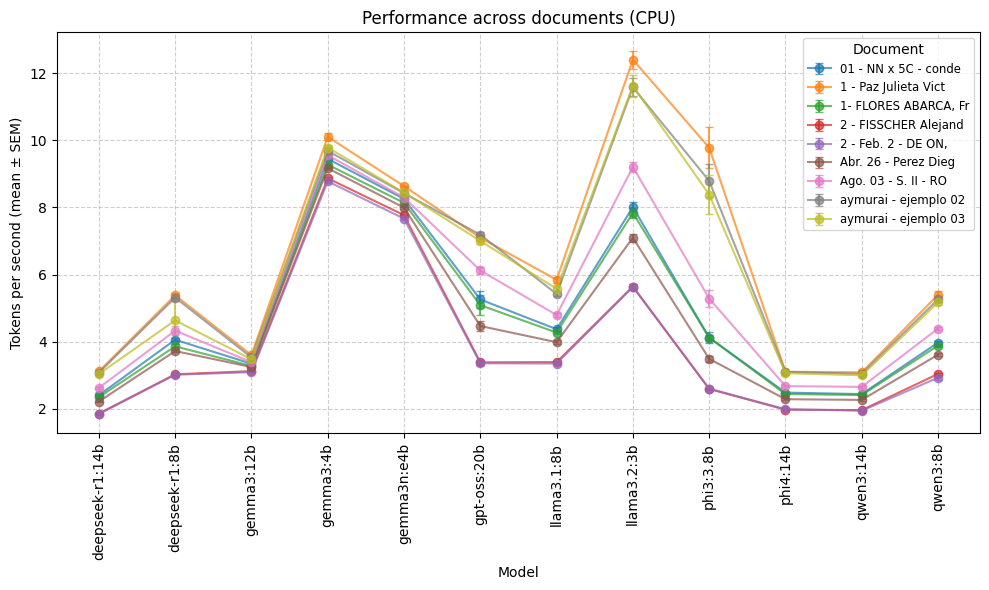

In [204]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute mean and std per document/model/device
df_summary = (
    df.groupby(['doc_path', 'model', 'device'])['tokens_per_second']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
df_summary['sem'] = df_summary['std'] / df_summary['count']**0.5  # standard error

# Sort models for consistent order
#order = sorted(df_summary['model'].unique())

# --- Plot for each device type ---
for device in ['cuda', 'cpu']:
    df_device = df_summary[df_summary['device'] == device]

    plt.figure(figsize=(10,6))
    
    # Plot one line per document
    for doc, df_doc in df_device.groupby('doc_path'):
        doc_name = doc.split('/')[-1][:20]
        plt.errorbar(
            df_doc['model'], df_doc['mean'],
            yerr=df_doc['sem'], fmt='-o',
            capsize=3, alpha=0.7, label=doc_name
        )
    
    plt.xticks(rotation=90)
    plt.xlabel("Model")
    plt.ylabel("Tokens per second (mean ± SEM)")
    plt.title(f"Performance across documents ({device.upper()})")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Document", fontsize='small', loc = 'best')# bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


### Output outliers/hallucinations visualizations

We see the last 100 characters of each output that was truncated (df['output_tokens']>16000)

In [188]:
N = 100
for idx, txt in enumerate(df_truncated['chat_response'].astype(str).fillna('')):
    print(f"+++++++++++++ Truncated summary {idx} (model={df_truncated.iloc[idx].get('model', '')}, system_prompt_type={df_truncated.iloc[idx].get('system_prompt_type', '')}, doc_path={df_truncated.iloc[idx].get('doc_path', '')}) +++++++++++++")
    print(txt[-N:])
    print("\n")

+++++++++++++ Truncated summary 0 (model=deepseek-r1:8b, system_prompt_type=baseline, doc_path=1- FLORES ABARCA, Francisco Alexander s 149 bis J-01-00369422-0-2022-1 Sala Feria (II) nnya vict do apela pp.pdf) +++++++++++++

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d

d




+++++++++++++ Truncated summary 1 (model=deepseek-r1:8b, system_prompt_type=baseline, doc_path=Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 NNAPES inadmisible RI AT x prision domiciliaira rechazada .pdf) +++++++++++++
. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 




+++++++++++++ Truncated summary 2 (model=deepseek-r1:8b, system_prompt_type=task-specific, doc_path=Ago. 03 - S. II - ROA Mirtha Elizabeth x 14 2 NNAPES inadmisible RI AT x prision domiciliaira rechazada .pdf) +++++++++++++
. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 

. 




+++++++++++++ Truncated s

In [189]:
# summaries -> df.chat_response.nunique()
# if input_token = 16384, it is trunckated
# model_duration_ms  [miliseconds] -> total time to analyze 

In [190]:
set(df.system_prompt)

{'Eres un analista legal especializado en elaborar resúmenes de resoluciones y documentos jurídicos.\nTu tarea es condensar la información esencial: hechos, cuestiones jurídicas, fundamentos y decisión.\nMantén precisión terminológica y evita inferencias no textuales. Si algún elemento no aparece en el texto, no lo inventes.\n',
 'Eres un asistente especializado en el análisis de documentos judiciales.\nDebes elaborar un resumen conciso del texto recibido, priorizando la información más relevante e identificando:\n\n\n    - Hechos relevantes (qué ocurrió).\n    - Actores clave (quiénes están involucrados).\n        * Denunciante(s).\n        * Denunciado(s).\n        * Testigo(s).\n        * Juez(es).\n        * Abogado(s).\n        * Fiscal(es).\n        * Perito(s).\n        * Otros (especificar).\n    - Cronología (cuándo ocurrieron los hechos y eventos procesales importantes).\n    - Lugar(es) (dónde ocurrieron los hechos y eventos procesales importantes).\n    - Fundamentos (norma

In [191]:
set(df.system_prompt_type)

{'baseline', 'task-specific', 'template'}

In [192]:
cuda_summaries[1]

{'model': 'llama3.1:8b',
 'options': {'num_ctx': 16384},
 'system_prompt': 'Eres un analista legal especializado en elaborar resúmenes de resoluciones y documentos jurídicos.\nTu tarea es condensar la información esencial: hechos, cuestiones jurídicas, fundamentos y decisión.\nMantén precisión terminológica y evita inferencias no textuales. Si algún elemento no aparece en el texto, no lo inventes.\n',
 'user_prompt': 'CUIJ J-01-00369422-0/2022-1 EXP. MPT 13904/2022-1 NUMERO: DI-64/2023-\nPoder Judicial de la Ciudad Autónoma de Buenos Aires Ministerio Público Tutelar\nAsesoría Tutelar Ante La Cámara De Apelaciones Del Fuero Penal, Penal Juvenil, Contravencional Y De Faltas "1983-2023. 40 Años de Democracia"\nDICTAMEN\nNúmero: DI-64/2023-ATCPCYF\nCiudad Autónoma de Buenos Aires, 5 de enero de 2023\nSeñores Jueces de Cámara:\nErnesto Blanck, interinamente a cargo de la Asesoría Tutelar ante la Cámara de Apelaciones en lo Penal, Contravencional y de Faltas (conf. Res. AGT Nro. 286/22), ant